# **Unstructured datasets**: PubLayNet (scientific document layouts with OCR text) and CORD-19 (full-text COVID-19 research articles). 

 ## STEP 1. **Balanced sample of 150 CORD-19 .json files**

In [1]:
import os
import tarfile
import random
import shutil

# Paths to my four .tar.gz archives
archives = [r"C:\Users\Lenovo\Downloads\biorxiv_medrxiv.tar.gz",
    r"C:\Users\Lenovo\Downloads\comm_use_subset.tar.gz",
    r"C:\Users\Lenovo\Downloads\noncomm_use_subset.tar.gz",
    r"C:\Users\Lenovo\Downloads\pmc_custom_license.tar.gz"]

# Temporary extraction folder
temp_extract_dir = r"C:\Users\Lenovo\Downloads\cord19_temp_extract"
# Final output directory for research sample
sample_output_dir = r"C:\Users\Lenovo\Downloads\cord19_research_sample"

# Cleanning previous extractions
if os.path.exists(temp_extract_dir):
    shutil.rmtree(temp_extract_dir)
os.makedirs(temp_extract_dir, exist_ok=True)

if os.path.exists(sample_output_dir):
    shutil.rmtree(sample_output_dir)
os.makedirs(sample_output_dir, exist_ok=True)

# Extract all files
print("Extracting files from archives...")
for archive_path in archives:
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=temp_extract_dir)

# Collect all JSON files
print("Collecting JSON files...")
json_files = []
for root, dirs, files in os.walk(temp_extract_dir):
    for file in files:
        if file.endswith(".json"):
            json_files.append(os.path.join(root, file))

print(f"Found {len(json_files)} JSON files.")

# Sample 150 files
sample_size = min(150, len(json_files))
sampled_files = random.sample(json_files, sample_size)

# Copy sampled files
print(f"Copying {sample_size} files to research sample directory...")
for i, filepath in enumerate(sampled_files):
    filename = f"sample_{i+1:03d}.json"
    shutil.copy(filepath, os.path.join(sample_output_dir, filename))

print(f"\n  Sample created at: {sample_output_dir}")


Extracting files from archives...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8608\3817017785.py:32: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=temp_extract_dir)


Found 13202 JSON files.
Copying 150 files to research sample directory...
✅ Sample created at: C:\Users\Lenovo\Downloads\cord19_research_sample


#### **CORD-19:** Compact research sample of ~150 full-text scientific papers (JSON)

## STEP 2. **Balanced sample of ~150 .json annotation files from PubLayNet** 

In [1]:
import os
import tarfile
import random

archive_path = r"C:\Users\Lenovo\Downloads\publaynet-train-000000.tar"
sample_output_dir = r"C:\Users\Lenovo\Downloads\publaynet_research_sample"

# Open tar once to list all members
with tarfile.open(archive_path, 'r') as tar:
    json_members = [m for m in tar.getmembers() if m.name.endswith('.json')]
    png_members = [m for m in tar.getmembers() if m.name.endswith('.png')]

print(f"Found {len(json_members)} JSON files and {len(png_members)} PNG files in archive.")

# Determine sample size
sample_size = min(150, int(0.1 * len(json_members)) if len(json_members) > 1500 else len(json_members))
sample_jsons = random.sample(json_members, sample_size)

print(f"Sampling {sample_size} files...")

# Create a lookup dict for PNG files by basename without extension
png_dict = {os.path.splitext(os.path.basename(m.name))[0]: m for m in png_members}

os.makedirs(sample_output_dir, exist_ok=True)

with tarfile.open(archive_path, 'r') as tar:
    for json_member in sample_jsons:
        # Extract JSON file
        tar.extract(json_member, path=sample_output_dir)

        # Get base filename without extension
        base_name = os.path.splitext(os.path.basename(json_member.name))[0]

        # If matching PNG exists, extract it
        if base_name in png_dict:
            tar.extract(png_dict[base_name], path=sample_output_dir)
        else:
            print(f"Warning: PNG for {base_name} not found in archive.")

print(f"\n  Sample with JSON + PNG files created at: {sample_output_dir}")


Found 985 JSON files and 985 PNG files in archive.
Sampling 150 files...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10560\1355033413.py:29: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(json_member, path=sample_output_dir)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10560\1355033413.py:36: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extract(png_dict[base_name], path=sample_output_dir)


✅ Sample with JSON + PNG files created at: C:\Users\Lenovo\Downloads\publaynet_research_sample


#### **PubLayNet:** Compact research sample of 150 structured document layouts (JSON annotations + PNG files)

## STEP 3. **Entropy + Sparsity for Both Samples**

#### **Goal:** to compare “ballast-ness” in PubLayNet vs. CORD-19 so you can decide which one is more efficient (i.e., informative vs. redundant) for your ballast detection modeling.

In [2]:
import os
import json
import numpy as np
from collections import Counter
from math import log2

# CONFIG
cord19_sample_dir = r"C:\Users\Lenovo\Downloads\cord19_research_sample"
publaynet_sample_dir = r"C:\Users\Lenovo\Downloads\publaynet_research_sample"

# FUNCTIONS

def shannon_entropy(values):
    """Calculate Shannon entropy for a list of categorical values"""
    counter = Counter(values)
    total = sum(counter.values())
    probs = [count / total for count in counter.values()]
    return -sum(p * log2(p) for p in probs if p > 0)

def analyze_sample(sample_dir):
    field_entropies = {}
    field_missingness = {}
    num_files = 0

    # Loop through JSON files
    for fname in os.listdir(sample_dir):
        if not fname.endswith(".json"):
            continue

        num_files += 1
        with open(os.path.join(sample_dir, fname), 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
            except json.JSONDecodeError:
                continue

            if isinstance(data, dict):
                fields = data.keys()
            else:
                continue

            for field in fields:
                value = data[field]

                if field not in field_entropies:
                    field_entropies[field] = []
                    field_missingness[field] = 0

                # Count missing
                if value in [None, '', [], {}, 'null']:
                    field_missingness[field] += 1
                else:
                    if isinstance(value, list):
                        field_entropies[field].append(str(len(value)))
                    elif isinstance(value, dict):
                        field_entropies[field].append(str(len(value.keys())))
                    else:
                        field_entropies[field].append(str(value))

    # Compute entropy & missingness %
    results = []
    for field in field_entropies:
        if len(field_entropies[field]) > 0:
            entropy = shannon_entropy(field_entropies[field])
        else:
            entropy = 0

        missing_pct = field_missingness[field] / num_files * 100
        results.append({'field': field,
            'entropy': round(entropy, 4),
            'missing_pct': round(missing_pct, 2)})

    return results

# ANALYSING BOTH
print("Analyzing CORD-19 sample...")
cord19_stats = analyze_sample(cord19_sample_dir)
print("Analyzing PubLayNet sample...")
publaynet_stats = analyze_sample(publaynet_sample_dir)

# SUMMARISING
def summarize(stats, name):
    entropies = [r['entropy'] for r in stats]
    missingness = [r['missing_pct'] for r in stats]

    print(f"\n Summary for {name}:")
    print(f"Number of fields: {len(stats)}")
    print(f"Mean entropy: {np.mean(entropies):.4f}")
    print(f"Median entropy: {np.median(entropies):.4f}")
    print(f"Mean missingness: {np.mean(missingness):.2f}%")
    print(f"Median missingness: {np.median(missingness):.2f}%")

summarize(cord19_stats, "CORD-19")
summarize(publaynet_stats, "PubLayNet")

print("\n Stats to decide which dataset has higher ballast.")

Analyzing CORD-19 sample...
Analyzing PubLayNet sample...

 Summary for CORD-19:
Number of fields: 7
Mean entropy: 3.7164
Median entropy: 3.9200
Mean missingness: 6.10%
Median missingness: 0.00%

 Summary for PubLayNet:
Number of fields: 5
Mean entropy: 4.8196
Median entropy: 3.9561
Mean missingness: 0.00%
Median missingness: 0.00%

 Stats to decide which dataset has higher ballast.


### **Interpretation**
#### *(1) Entropy*

PubLayNet has higher mean entropy → Its structured fields carry more diverse information.
CORD-19’s lower mean entropy suggests more repetitive or low-information fields.

#### *(2) Sparsity*

PubLayNet has no missing fields → Very dense, no gaps in the structure.
CORD-19 has ~6 % mean missingness → Some parts might be sparse ballast.

#### *(3) Content type*

PubLayNet: fewer fields but dense, structured, visual layout info → ballast is likely in redundant box labels or layout features.

CORD-19: text + metadata → likely ballast in repetitive text, citations, or boilerplate sections.

### **Practical conclusion**
If I want to study ballast in highly structured, high-entropy data, *PubLayNet* is better.
If I want to study ballast in unstructured text and metadata, *CORD-19* is better, but it’s slightly more sparse and repetitive.

## **Ballast Detection & Comparison**
### CORD-19 (text, metadata) and PubLayNet (layout JSON)

## STEP 4. **Baseline profiling**

***Baseline profiling*** usually means creating a comprehensive **initial summary** of your dataset’s key characteristics before doing any transformations, modeling, or advanced analysis.  
It answers: **What does the raw data look like?**

---

 **Typical baseline profiling includes:**

- **Basic statistics** (mean, median, min, max, standard deviation)
- **Distributions of variables** (histograms, boxplots)
- **Missing values** (how much? where?)
- **Outliers**
- **Correlations**
- **Data types & cardinality** (e.g., number of unique categories)

---

This **baseline** serves as your reference point to measure the **impact of preprocessing or data cleaning**. For example:  

> “After preprocessing, we reduced missing values from 15% to 2% — this improvement is evident because we did baseline profiling.”



In [1]:
import os
import json
import math
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def calculate_entropy(values):
    """Compute entropy given a list of values."""
    counter = Counter(values)
    total = len(values)
    entropy = -sum((count/total) * math.log2(count/total) for count in counter.values() if count > 0)
    return entropy

def detect_type(non_nulls):
    """Detect whether the field is numeric or categorical."""
    try:
        float_vals = [float(v) for v in non_nulls]
        return "numeric", float_vals
    except:
        return "categorical", non_nulls

def profile_dataset(dataset_dir, dataset_name):
    """Profile JSON files in the dataset directory."""
    all_fields = {}
    json_files = [
        os.path.join(dataset_dir, f) for f in os.listdir(dataset_dir) if f.endswith('.json')]

    print(f"\n                    Analyzing {dataset_name} sample...")
    for json_file in json_files:
        with open(json_file, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                for key, value in data.items():
                    if key not in all_fields:
                        all_fields[key] = []
                    all_fields[key].append(value)
            except json.JSONDecodeError:
                print(f"!!! Skipped corrupted file: {json_file}")

    field_stats = []
    numeric_fields_for_corr = {}

    for field, values in all_fields.items():
        non_nulls = [v for v in values if v not in [None, '', [], {}]]
        missing = (len(values) - len(non_nulls)) / len(values)

        # Convert unhashable types to strings
        hashable_values = []
        for v in non_nulls:
            if isinstance(v, (list, dict)):
                hashable_values.append(str(v))
            else:
                hashable_values.append(v)

        entropy = calculate_entropy(hashable_values) if hashable_values else 0

        dtype, processed_values = detect_type(hashable_values)

        stats = {"field": field, "dtype": dtype, "missing_pct": round(missing*100, 2), "entropy": round(entropy, 4)}

        if dtype == "numeric":
            arr = np.array(processed_values, dtype=float)
            stats.update({
                "mean": round(arr.mean(), 4),
                "std": round(arr.std(), 4),
                "min": round(arr.min(), 4),
                "max": round(arr.max(), 4),
                "median": round(np.median(arr), 4),
                "n_outliers": int(sum((arr < (np.percentile(arr, 25) - 1.5 * (np.percentile(arr, 75) - np.percentile(arr, 25)))) |
                                      (arr > (np.percentile(arr, 75) + 1.5 * (np.percentile(arr, 75) - np.percentile(arr, 25))))))})
            
            # Save for correlation
            numeric_fields_for_corr[field] = arr

            # Histogram
            plt.hist(arr, bins=20)
            plt.title(f"Histogram: {field}")
            plt.xlabel(field)
            plt.ylabel("Frequency")
            plt.tight_layout()
            plt.savefig(f"{dataset_name}_{field}_hist.png")
            plt.clf()

        else:
            unique_vals = set(processed_values)
            stats["cardinality"] = len(unique_vals)

        field_stats.append(stats)

    # Print summary table
    df_stats = pd.DataFrame(field_stats)
    print("\n   Field-level Summary:")
    print(df_stats.fillna("").to_string(index=False))

    # Compute correlation matrix
    if numeric_fields_for_corr:
        numeric_df = pd.DataFrame(dict(
            [(k, pd.Series(v)) for k, v in numeric_fields_for_corr.items()]))
        corr_matrix = numeric_df.corr()
        print("\n   Numeric field correlation matrix:")
        print(corr_matrix)

        # Optional: Save heatmap
        plt.figure(figsize=(8, 6))
        import seaborn as sns
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
        plt.title(f"{dataset_name} - Correlation Matrix")
        plt.tight_layout()
        plt.savefig(f"{dataset_name}_correlation_matrix.png")
        plt.clf()

    # Overall stats
    print(f"\n    Overall summary for {dataset_name}:")
    print(f"Total fields: {len(all_fields)}")
    print(f"Mean entropy: {df_stats['entropy'].mean():.4f}")
    print(f"Median entropy: {df_stats['entropy'].median():.4f}")
    print(f"Mean missingness: {df_stats['missing_pct'].mean():.2f}%")
    print(f"Median missingness: {df_stats['missing_pct'].median():.2f}%")

# Usage

cord19_dir = r"C:\Users\Lenovo\Downloads\cord19_research_sample"
publaynet_dir = r"C:\Users\Lenovo\Downloads\publaynet_research_sample"

profile_dataset(cord19_dir, "CORD-19")
profile_dataset(publaynet_dir, "PubLayNet")



                    Analyzing CORD-19 sample...

   Field-level Summary:
      field       dtype  missing_pct  entropy  cardinality
   paper_id categorical         0.00   7.2288          150
   metadata categorical         0.00   7.1755          147
   abstract categorical        14.67   7.0000          128
  body_text categorical         0.00   7.2288          150
bib_entries categorical         0.00   7.2288          150
ref_entries categorical         3.33   7.1799          145
back_matter categorical        24.67   6.8025          112

    Overall summary for CORD-19:
Total fields: 7
Mean entropy: 7.1206
Median entropy: 7.1799
Mean missingness: 6.10%
Median missingness: 0.00%

                    Analyzing PubLayNet sample...

   Field-level Summary:
      field       dtype  missing_pct  entropy cardinality       mean         std     min       max    median n_outliers
  file_name categorical          0.0   7.2288       150.0                                                         

<Figure size 640x480 with 0 Axes>

<Figure size 800x600 with 0 Axes>

## STEP 4'. **Baseline profiling** (Old version)

In [2]:
import os
import json
import math
from collections import Counter
import numpy as np

def calculate_entropy(values):
    """Compute entropy given a list of values."""
    counter = Counter(values)
    total = len(values)
    entropy = -sum((count/total) * math.log2(count/total) for count in counter.values())
    return entropy

def profile_dataset(dataset_dir, dataset_name):
    """Profile JSON files in the dataset directory."""
    all_fields = {}
    json_files = [
        os.path.join(dataset_dir, f) for f in os.listdir(dataset_dir) if f.endswith('.json')    ]

    print(f"\nAnalyzing {dataset_name} sample...")
    for json_file in json_files:
        with open(json_file, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                for key, value in data.items():
                    if key not in all_fields:
                        all_fields[key] = []
                    all_fields[key].append(value)
            except json.JSONDecodeError:
                print(f"Skipped corrupted file: {json_file}")

    entropies = []
    missingness = []

    for field, values in all_fields.items():
        non_nulls = [v for v in values if v not in [None, '', [], {}]]

        # Fix: Convert unhashable types to strings
        hashable_values = []
        for v in non_nulls:
            if isinstance(v, (list, dict)):
                hashable_values.append(str(v))
            else:
                hashable_values.append(v)

        if not hashable_values:
            entropy = 0
        else:
            entropy = calculate_entropy(hashable_values)

        missing = (len(values) - len(non_nulls)) / len(values)
        entropies.append(entropy)
        missingness.append(missing)

    mean_entropy = np.mean(entropies)
    median_entropy = np.median(entropies)
    mean_missing = np.mean(missingness)
    median_missing = np.median(missingness)

    print(f"\n   Summary for {dataset_name}:")
    print(f"Number of fields: {len(all_fields)}")
    print(f"Mean entropy: {mean_entropy:.4f}")
    print(f"Median entropy: {median_entropy:.4f}")
    print(f"Mean missingness: {mean_missing*100:.2f}%")
    print(f"Median missingness: {median_missing*100:.2f}%")

# Set directories
cord19_dir = r"C:\Users\Lenovo\Downloads\cord19_research_sample"
publaynet_dir = r"C:\Users\Lenovo\Downloads\publaynet_research_sample"

# Run profiling for both
profile_dataset(cord19_dir, "CORD-19")
profile_dataset(publaynet_dir, "PubLayNet")



Analyzing CORD-19 sample...

   Summary for CORD-19:
Number of fields: 7
Mean entropy: 7.1206
Median entropy: 7.1799
Mean missingness: 6.10%
Median missingness: 0.00%

Analyzing PubLayNet sample...

   Summary for PubLayNet:
Number of fields: 5
Mean entropy: 5.4742
Median entropy: 7.2288
Mean missingness: 0.00%
Median missingness: 0.00%


## STEP 5. **Ballast detection extension**

#### This includes:
##### ✅ **Entropy Analysis**
##### ✅ **Mutual Information (MI)**
##### ✅ **Basic Structural Stats**
##### ✅ **Before/After logging** to track ballast reduction impact

### STEP 5'. **MI Target Creation + Analysis**

## Why you need a target
**Mutual Information (MI)** quantifies how much knowing a feature reduces uncertainty about the target.
So you need:

A ***discrete/categorical column*** you care about predicting or classifying.
- Or a numeric column that you can discretize if needed.
- If you don’t have a true label, you can create a proxy label for demonstration - e.g. “*is_long_text*”, “*has_many_refs*”, “*has_figures*”.

In [3]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif

# === Helpers ===

def flatten_lists_in_series(series):
    """Convert list-type cells to comma-separated strings to make hashable."""
    if series.apply(lambda x: isinstance(x, list)).any():
        return series.apply(lambda x: ','.join(map(str, x)) if isinstance(x, list) else str(x))
    else:
        return series

def compute_mutual_information(df, target_col):
    """
    Compute mutual information of each feature with respect to the target.
    NaNs are handled safely.
    """
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col]

    for col in X.columns:
        X[col] = flatten_lists_in_series(X[col])

        if X[col].dtype == 'object':
            X[col] = X[col].astype('category').cat.codes
        else:
            X[col] = pd.to_numeric(X[col], errors='coerce')

    # Fill NaNs: numeric → 0, categorical (already coded) → -1
    for col in X.columns:
        if pd.api.types.is_numeric_dtype(X[col]):
            X[col] = X[col].fillna(0)
        else:
            X[col] = X[col].fillna(-1)

    if y.dtype == 'object':
        y = y.astype('category').cat.codes

    mi = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
    return dict(zip(X.columns, mi))


def compute_entropy(df):
    """Shannon entropy per column."""
    entropies = {}
    for col in df.columns:
        vals = flatten_lists_in_series(df[col])
        counts = vals.value_counts(dropna=False)
        probs = counts / counts.sum()
        entropy = -np.sum(probs * np.log2(probs + 1e-9))
        entropies[col] = entropy
    return entropies

def load_json_files_to_df(json_dir, sample_size=None):
    json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
    if sample_size and sample_size < len(json_files):
        json_files = np.random.choice(json_files, sample_size, replace=False)

    data = []
    for file in json_files:
        path = os.path.join(json_dir, file)
        with open(path, 'r', encoding='utf-8') as f:
            try:
                content = json.load(f)
                data.append(content)
            except Exception as e:
                print(f"Warning: Failed to load {file}: {e}")

    df = pd.json_normalize(data)
    return df

# === Dataset-specific Target Injection ===

def inject_cord19_target(df):
    """Create is_long_text target from body_text."""
    df['is_long_text'] = df['body_text'].apply(lambda x: 1 if len(str(x)) > 1000 else 0)
    return df, 'is_long_text'

def inject_publaynet_target(df):
    """Create has_table target from annotations."""
    def has_table(annots):
        if isinstance(annots, list):
            return int(any(a.get('category') == 'table' for a in annots))
        return 0
    df['has_table'] = df['annotations'].apply(has_table)
    return df, 'has_table'

# === Main Analysis Function ===

def analyze_dataset(json_dir, sample_size=None, dataset_type='cord19'):
    print(f"\n=== Analyzing {dataset_type.upper()} Dataset ===")
    df = load_json_files_to_df(json_dir, sample_size)
    print(f"Loaded {len(df)} records with {len(df.columns)} fields.")

    if dataset_type == 'cord19':
        df, target_col = inject_cord19_target(df)
    elif dataset_type == 'publaynet':
        df, target_col = inject_publaynet_target(df)
    else:
        raise ValueError("Unknown dataset_type.")

    print(f"Using target: {target_col}")

    # MI Analysis
    print("Computing Mutual Information...")
    mi = compute_mutual_information(df, target_col)
    mi_df = pd.DataFrame.from_dict(mi, orient='index', columns=['Mutual Information'])
    mi_df = mi_df.sort_values(by='Mutual Information', ascending=False)
    print("\nTop 10 fields by Mutual Information:")
    print(mi_df.head(10))

    return mi_df

# === Paths ===
cord19_sample_dir = r'C:\Users\Lenovo\Downloads\cord19_research_sample'
publaynet_sample_dir = r'C:\Users\Lenovo\Downloads\publaynet_research_sample'

sample_size = 150

# === Run MI Analysis ===
cord19_mi_df = analyze_dataset(cord19_sample_dir, sample_size, dataset_type='cord19')
publaynet_mi_df = analyze_dataset(publaynet_sample_dir, sample_size, dataset_type='publaynet')



=== Analyzing CORD19 Dataset ===
Loaded 150 records with 3510 fields.
Using target: is_long_text
Computing Mutual Information...

Top 10 fields by Mutual Information:
                                     Mutual Information
bib_entries.BIBREF300.other_ids.DOI            0.010000
bib_entries.BIBREF175.other_ids.DOI            0.006667
bib_entries.BIBREF300.venue                    0.006667
bib_entries.BIBREF256.ref_id                   0.003333
bib_entries.BIBREF294.authors                  0.003333
bib_entries.BIBREF252.venue                    0.003333
bib_entries.BIBREF66.ref_id                    0.003333
bib_entries.BIBREF304.ref_id                   0.003333
bib_entries.BIBREF297.title                    0.003333
ref_entries.FIGREF26.text                      0.003333

=== Analyzing PUBLAYNET Dataset ===
Loaded 150 records with 5 fields.
Using target: has_table
Computing Mutual Information...

Top 10 fields by Mutual Information:
             Mutual Information
file_name          

#### CORD-19  
**Target:** `is_long_text`
- The highest MI is **0.01** for `bib_entries.BIBREF300.other_ids.DOI` — that’s very low.  
- Everything else is even smaller, near **0.003–0.006**.

**Insight:**  
These fields do not provide strong predictive value for your `is_long_text` target →  
Low MI → likely **ballast** (for this specific target).

  This matches your entropy stage: many `BIBREF` subfields look unique but don’t impact your chosen task → **ballast candidate**.

---

#### PubLayNet  
**Target:** `has_table`
- Every field has MI ≈ **0** — which means none of them help predict `has_table`.

**Insight:**  
All fields are effectively **ballast** for this target.  
(But keep domain logic in mind: e.g., annotations probably should be kept if you plan layout detection later.)


## STEP 5 (continued). **Ballast detection extension**

In [1]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif

def flatten_lists_in_series(series):
    """Convert list-type cells to comma-separated strings to make hashable."""
    if series.apply(lambda x: isinstance(x, list)).any():
        return series.apply(lambda x: ','.join(map(str, x)) if isinstance(x, list) else str(x))
    else:
        return series

def compute_entropy(df):
    """
    Compute Shannon entropy for each column in a DataFrame.
    Handles list-type columns by flattening them to strings first.
    """
    entropies = {}
    for col in df.columns:
        vals = df[col]
        vals = flatten_lists_in_series(vals)
        counts = vals.value_counts(dropna=False)
        probs = counts / counts.sum()
        entropy = -np.sum(probs * np.log2(probs + 1e-9))
        entropies[col] = entropy
    return entropies

def compute_mutual_information(df, target_col):
    """
    Compute mutual information of each feature in df with respect to the target column.
    Assumes df includes the target_col.
    """
    X = df.drop(columns=[target_col]).copy()
    y = df[target_col]

    # Flatten list-like and encode categorical
    for col in X.columns:
        X[col] = flatten_lists_in_series(X[col])
        if X[col].dtype == 'object':
            X[col] = X[col].astype('category').cat.codes

    # Handle missing values: fill or drop
    X = X.fillna(-999)
    if y.dtype == 'object':
        y = y.astype('category').cat.codes
    y = pd.Series(y).fillna(-999)

    # Ensure all numeric
    X = X.apply(pd.to_numeric, errors='coerce')
    X = X.fillna(-999)  # Re-fill after coercion

    mi = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
    return dict(zip(X.columns, mi))


def load_json_files_to_df(json_dir, sample_size=None):
    """
    Load JSON files from a directory into a single DataFrame.
    """
    json_files = [f for f in os.listdir(json_dir) if f.endswith('.json')]
    if sample_size and sample_size < len(json_files):
        json_files = np.random.choice(json_files, sample_size, replace=False)

    data = []
    for file in json_files:
        path = os.path.join(json_dir, file)
        with open(path, 'r', encoding='utf-8') as f:
            try:
                content = json.load(f)
                data.append(content)
            except Exception as e:
                print(f"Warning: Failed to load {file}: {e}")

    df = pd.json_normalize(data)
    return df

def analyze_dataset(json_dir, sample_size=None, target_col=None):
    print(f"\n=== Analyzing Dataset: {json_dir} ===")
    df = load_json_files_to_df(json_dir, sample_size)
    print(f"Loaded {len(df)} records with {len(df.columns)} fields.")

    print("\n== Structural Stats BEFORE ==")
    print(f"Total fields: {len(df.columns)}")
    print(f"Total records: {len(df)}")

    # === Add target if needed ===
    if target_col and target_col not in df.columns:
        print(f"⚙️ Adding target column '{target_col}' manually ...")
        if target_col == 'is_long_text' and 'body_text' in df.columns:
            df[target_col] = df['body_text'].apply(lambda x: len(str(x)) > 1000)
        elif target_col == 'has_table' and 'annotations' in df.columns:
            df[target_col] = df['annotations'].apply(lambda x: 'table' in str(x).lower())

    print("\nComputing Entropy...")
    entropy = compute_entropy(df)
    entropy_df = pd.DataFrame.from_dict(entropy, orient='index', columns=['Entropy']).sort_values(by='Entropy', ascending=False)
    print(entropy_df.head(10))

    if target_col and target_col in df.columns:
        print(f"\nComputing Mutual Information with target column '{target_col}' ...")
        mi = compute_mutual_information(df, target_col)
        mi_df = pd.DataFrame.from_dict(mi, orient='index', columns=['Mutual Information']).sort_values(by='Mutual Information', ascending=False)
        print(mi_df.head(10))
    else:
        print(f"\n!!!! Target column '{target_col}' not found. Skipping MI.")
        mi_df = None

    print("\n== Structural Stats AFTER ==")
    print(f"Total fields: {len(df.columns)}")
    print(f"Total records: {len(df)}")

    return entropy_df, mi_df

# === Configuration ===
cord19_sample_dir = r'C:\Users\Lenovo\Downloads\cord19_research_sample'
publaynet_sample_dir = r'C:\Users\Lenovo\Downloads\publaynet_research_sample'

sample_size = 150

# Use the correct target for each dataset
cord19_target = 'is_long_text'
publaynet_target = 'has_table'

# === Run Analysis ===
cord19_entropy, cord19_mi = analyze_dataset(cord19_sample_dir, sample_size, cord19_target)
publaynet_entropy, publaynet_mi = analyze_dataset(publaynet_sample_dir, sample_size, publaynet_target)



=== Analyzing Dataset: C:\Users\Lenovo\Downloads\cord19_research_sample ===
Loaded 150 records with 3510 fields.

== Structural Stats BEFORE ==
Total fields: 3510
Total records: 150
⚙️ Adding target column 'is_long_text' manually ...

Computing Entropy...
                             Entropy
paper_id                    7.228818
body_text                   7.228818
bib_entries.BIBREF1.title   7.124754
bib_entries.BIBREF6.title   7.068818
bib_entries.BIBREF2.title   7.068818
metadata.title              7.038623
metadata.authors            7.038623
bib_entries.BIBREF0.title   6.985290
bib_entries.BIBREF5.title   6.928688
bib_entries.BIBREF12.title  6.908114

Computing Mutual Information with target column 'is_long_text' ...
                                     Mutual Information
bib_entries.BIBREF300.other_ids.DOI            0.010000
bib_entries.BIBREF175.other_ids.DOI            0.006667
bib_entries.BIBREF300.venue                    0.006667
bib_entries.BIBREF279.other_ids.DOI         

#### **Summary**
**Entropy** tells us how much **variation** each field carries → fields with zero entropy = same value = no info.
**Mutual Information** shows how much each field contributes to predicting the target:
- High MI = useful.
- Low MI ≈ 0 = ballast for the target.

#### Inspect one file:

This shows what’s inside:
- Is it a dict with nested keys?
- Is it a list of dicts?

## STEP 6'. **Mutual Information + Entropy** (CORD19 dataset)
### Saving the full results to CSV-files: **cord19_entropy.csv** and **cord19_mi.csv**

### CORD-19 ➜ Vectorize ➜ Mutual Information + Entropy

This notebook does the following:

- **Loads** CORD-19 JSON files (abstract + body text)  
- **Merges** all text by document ID  
- **Vectorizes** all tokens using `CountVectorizer` **without limiting features**  
- **Calculates** per-token **Mutual Information** (with a dummy label for demonstration)  
- **Calculates** per-token **entropy** across the document collection  
- **Saves** the full results to CSV files: `cord19_entropy.csv` and `cord19_mi.csv`

#### **What Does This Code Do?**
**CORD-19 ➜ Tokenize ➜ Mutual Information + Entropy**

Steps:
1. Extracts **abstract** and **body_text** from each paper’s JSON file  
2. Combines all text sections by `doc_id` into one document  
3. Uses `CountVectorizer` for simple sparse token counts (**no TF-IDF headaches**)  
4. Computes **per-token Mutual Information (MI)** using a dummy binary target — just to show how MI scores differ across documents  
5. Computes **entropy** for each token’s distribution across all documents  
6. Outputs full results to `cord19_entropy.csv` and `cord19_mi.csv`

#### **Key Design Points**

- **Simple CountVectorizer:** Good for large-scale, sparse text data  
- **No feature limit:** Uses all tokens to get a complete distribution  
- **Disjoint phases:** Load → Vectorize → MI → Entropy → Save — makes each step easy to debug  
- **Entropy:** Uses `.sum(axis=0)` once for computing token probabilities across the entire collection

#### **Entropy for text tokens**

For text features, the standard entropy is:  
**H(token) = – Σ pᵢ · log₂(pᵢ)**  
where pᵢ is the probability of that token across all documents.

- **Lower entropy** means the token is very document-specific (potentially high signal for document classification).
- **Higher mutual information (MI)** means the token carries more useful signal for predicting the target label.

#### **Output files:**  
- `cord19_entropy.csv` — per-token entropy  
- `cord19_mi.csv` — per-token mutual information  

In [1]:
import os
import glob
import json
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import entropy
import numpy as np

# -------------------
# Load CORD-19 files
# -------------------
def load_cord19(folder):
    rows = []
    files = glob.glob(os.path.join(folder, '*.json'))
    for file in files:
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)
        doc_id = os.path.basename(file)
        for section in data.get('abstract', []):
            rows.append({'doc_id': doc_id, 'text': section.get('text', '')})
        for section in data.get('body_text', []):
            rows.append({'doc_id': doc_id, 'text': section.get('text', '')})
    df = pd.DataFrame(rows)
    return df

# -----------------
# Compute Entropy
# -----------------
def compute_entropy(X):
    probs = X.sum(axis=0) / X.sum()
    ent = entropy(probs, base=2)
    return ent

# -----
# Run
# -----
if __name__ == '__main__':
    folder = r"C:\Users\Lenovo\Downloads\cord19_research_sample"

    # 1. Load
    df = load_cord19(folder)
    texts = df.groupby('doc_id')['text'].apply(lambda x: ' '.join(x)).tolist()

    # 2. Vectorize
    vectorizer = CountVectorizer(max_features=None, stop_words='english')
    X = vectorizer.fit_transform(texts)
    features = vectorizer.get_feature_names_out()

   
    # 3. Entropy
    probs = np.array(X.sum(axis=0)).flatten() / X.sum()
    entropies = -probs * np.log2(probs + 1e-12)
    entropies = np.nan_to_num(entropies)
    df_entropy = pd.DataFrame({
        'feature': features,
        'entropy': entropies
    }).sort_values(by='entropy', ascending=False)

    df_entropy.to_csv('cord19_entropy.csv', index=False, encoding='utf-8')
    print("  Saved: cord19_entropy.csv")

    # 4. Mutual Information (Example: Dummy target for demonstration)
    y = [0] * (len(texts)//2) + [1] * (len(texts) - len(texts)//2)
    mi_scores = mutual_info_classif(X, y, discrete_features=True)
    df_mi = pd.DataFrame({
        'feature': features,
        'mutual_info': mi_scores
    }).sort_values(by='mutual_info', ascending=False)

    df_mi.to_csv('cord19_mi.csv', index=False, encoding='utf-8')
    print("  Saved: cord19_mi.csv")


✅ Saved: cord19_entropy.csv
✅ Saved: cord19_mi.csv


In [2]:
#!pip install pillow pytesseract

In [3]:
#import pytesseract
#print(pytesseract.get_tesseract_version())

5.5.0.20241111


## STEP 6''. **Mutual Information + Entropy** (PUBLAYNET dataset)
### Saving the full results to CSV-files: **publaynet_entropy.csv** and **publaynet_mi.csv**

### Publaynet OCR ➜ Vectorize ➜ Mutual Information + Entropy

This notebook does the following:

- **Extracts** all textual fields from bounding boxes using OCR  
- **Vectorizes** all tokens using `CountVectorizer` **without limiting features**  
- **Calculates** per-token **Mutual Information** with the layout category labels  
- **Calculates** per-token **entropy** across the category distribution  
- **Saves** the full results to CSV files: `publaynet_entropy.csv` and `publaynet_mi.csv`

#### **What Does This Code Do?**
**Publaynet OCR ➜ Tokenize ➜ Mutual Information + Entropy**

Steps:
1. Extract OCR text for each annotation bounding box  
2. Use `CountVectorizer` for simple sparse token counts (no TF-IDF headaches)  
3. Compute **Mutual Information (MI)** between each token and layout categories  
4. Compute **entropy** for each token’s distribution across categories  
5. Output CSVs with all tokens ranked by MI and entropy

#### **Key Design Points**
- **CountVectorizer:** Keeps it simple and robust for sparse text data  
- **Disjoint phases:** Clear steps make it easy to debug or reuse each part  
- **LabelEncoder:** Ensures clean multi-class handling  
- **Entropy:** Uses `.toarray()` once, so it works well for sparse matrices

#### **Entropy for text tokens**


For text features, the standard entropy is:  
H(token) = – Σ pᵢ · log₂(pᵢ)  
where pᵢ is the probability of that token appearing in each cateory.

- **Lower entropy** means the token is more specific to certain casses.
- **Higher mutual information (MI)** means the token carries more useful signal for predicting the layout category

In [1]:
import os
import json
from PIL import Image
import pytesseract

import numpy as np
import pandas as pd

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from scipy.stats import entropy

# Tesseract executable path
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Data directory
SAMPLE_DIR = r"C:\Users\Lenovo\Downloads\publaynet_research_sample"


# ---------------------------
# Extract OCR text + labels
# ---------------------------

texts = []
labels = []

json_files = [f for f in os.listdir(SAMPLE_DIR) if f.endswith('.json')]
print(f"Found {len(json_files)} JSON files.\n")

for idx, jf in enumerate(json_files, 1):
    json_path = os.path.join(SAMPLE_DIR, jf)
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    base_name = os.path.splitext(jf)[0]
    img_path = os.path.join(SAMPLE_DIR, base_name + '.png')

    if not os.path.exists(img_path):
        print(f"Image missing for {base_name}, skipping...")
        continue

    image = Image.open(img_path)

    for ann in data.get('annotations', []):
        category = ann['category_name']
        bbox = ann['bbox']  # [x, y, w, h]
        x, y, w, h = map(int, bbox)
        cropped = image.crop((x, y, x + w, y + h))
        text = pytesseract.image_to_string(cropped, lang='eng').strip()
        if text:
            texts.append(text)
            labels.append(category)

    if idx % 10 == 0 or idx == len(json_files):
        print(f"Processed {idx}/{len(json_files)} files...")

print(f"\n   Extracted {len(texts)} text samples from {len(json_files)} files.")
print(f"Categories: {set(labels)}")


# -------------------------------
# Vectorize with CountVectorizer
# -------------------------------

vectorizer = CountVectorizer(token_pattern=r'\b\w+\b', lowercase=True, min_df=2)
X_counts = vectorizer.fit_transform(texts)
tokens = vectorizer.get_feature_names_out()

print(f"\n   Vectorized into {len(tokens)} tokens over {X_counts.shape[0]} samples.")


# ---------------------------
# Encode labels numerically
# ---------------------------

le = LabelEncoder()
y = le.fit_transform(labels)

print(f"Classes: {le.classes_}")


# -----------------------------
# Compute Mutual Information
# -----------------------------

print("Computing Mutual Information...")
mi = mutual_info_classif(X_counts, y, discrete_features=True, random_state=42)


# -----------------------------------------
# Compute per-token entropy across classes
# -----------------------------------------

def compute_token_class_entropy(X_counts, y, num_classes):
    X_array = X_counts.toarray()
    entropies = []

    for j in range(X_array.shape[1]):  # for each token
        token_presence = X_array[:, j] > 0
        class_counts = Counter(y[token_presence])
        total = sum(class_counts.values())
        if total == 0:
            entropies.append(0)
            continue
        probs = np.array([class_counts.get(c, 0) / total for c in range(num_classes)])
        ent = entropy(probs, base=2)
        entropies.append(ent)

    return np.array(entropies)

print("Computing per-token entropy (class distribution)...")
token_entropy = compute_token_class_entropy(X_counts, y, num_classes=len(le.classes_))


# -------------
# Save results
# -------------

df_mi = pd.DataFrame({'token': tokens, 'mutual_information': mi})
df_entropy = pd.DataFrame({'token': tokens, 'entropy': token_entropy})

df_mi.sort_values(by='mutual_information', ascending=False).to_csv('publaynet_mi.csv', index=False)
df_entropy.sort_values(by='entropy', ascending=True).to_csv('publaynet_entropy.csv', index=False)

print("\n   Saved:")
print(" - publaynet_mi.csv  (tokens ranked by mutual information)")
print(" - publaynet_entropy.csv  (tokens ranked by entropy)")

Found 150 JSON files.

Processed 10/150 files...
Processed 20/150 files...
Processed 30/150 files...
Processed 40/150 files...
Processed 50/150 files...
Processed 60/150 files...
Processed 70/150 files...
Processed 80/150 files...
Processed 90/150 files...
Processed 100/150 files...
Processed 110/150 files...
Processed 120/150 files...
Processed 130/150 files...
Processed 140/150 files...
Processed 150/150 files...

   Extracted 1304 text samples from 150 files.
Categories: {'figure', 'title', 'list', 'table', 'text'}

    Vectorized into 6714 tokens over 1304 samples.
Classes: ['figure' 'list' 'table' 'text' 'title']
Computing Mutual Information...
Computing per-token entropy (class distribution)...

   Saved:
 - publaynet_mi.csv  (tokens ranked by mutual information)
 - publaynet_entropy.csv  (tokens ranked by entropy)


In [4]:
df_mi.head(10)

,token,mutual_information
0,0,0.031955
1,00,0.006718
2,000,0.002114
3,0001,0.004389
4,0002,0.000417
5,001,0.003760
6,002,0.000417
7,003,0.001883
8,004,0.000417
9,005,0.001899


In [5]:
df_entropy.head(10)

,token,entropy
0,0,0.739495
1,00,1.451661
2,000,1.148835
3,0001,0.543564
4,0002,0.000000
5,001,0.816689
6,002,0.000000
7,003,0.918296
8,004,0.000000
9,005,0.650022


### In addition to STEP 6''
### **Simple test snippet to check OCR on a single image**

In [2]:
from PIL import Image
import pytesseract

# Make sure this path matches your Tesseract installation
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Replace this with a path to any PNG image with text you want to test
test_image_path = r"C:\Users\Lenovo\Downloads\publaynet_research_sample\PMC4305197_00004.png"

# Open image
image = Image.open(test_image_path)

# Run OCR
text = pytesseract.image_to_string(image, lang='eng')

print("OCR output:")
print(text)


OCR output:
28 _MoconR EP AL.

‘Change in Normalized Carpal Tanna Pressure (ret)

‘it Angular Displacement (Degrees)

Teo soe? rah Poe and Np spacings

‘the investigation. Changes in tunnel pressures with
resistance to wrist motion evaluated in a contrlled
fahion through a large range of writ motions were
quantified In population of bealthy wrists. To our
Jnowldge, this study ie alo the fist to report on CTP
changes in responce to motions other than the cardinal
‘west motion planes of exioniextension ar radial/ulnar
deviation. Overall the data suggests that when com
pound motions are involved, as would be typical af
Idusteal activities, pressures within the carpal tu
nel tend to fall between those observed in the eardin
planes of Wrist fexionfstension and. radial/ulnar
deviation

"The results alao showed that CTP changed with
ferent grip applications, and pressures were gener
ally greater with active pinch and power grips as
‘compared to trials where there was no active gripping.
Overa

## STEP 7'. **Generalized Indicators CORD19**
### ***/ merge, normalize, Ballast_Score, Keep/Drop, scatter plot, summary stats /***

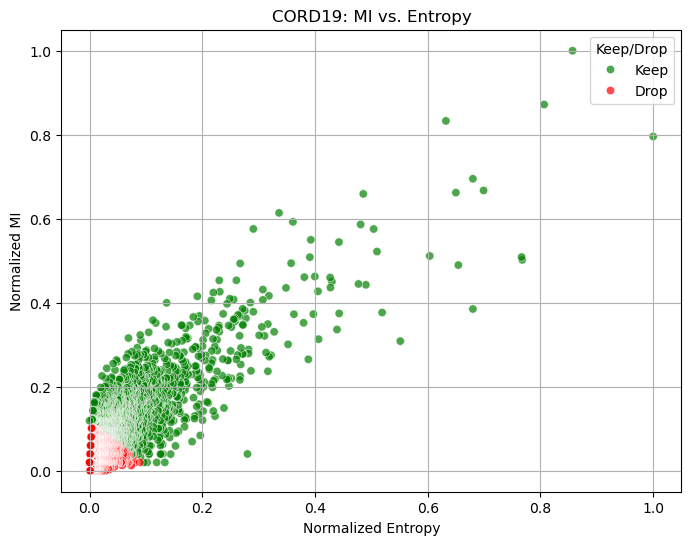


Ballast_threshold = 0.89

                         Metric         Value
0                Total features  28600.000000
1              Dropped features  26372.000000
2                     % Dropped     92.209790
3            Mean Ballast_Score      0.956541
4  Mean Ballast_Score (Dropped)      0.970405
5     Mean Ballast_Score (Kept)      0.792431
6                Mean MI (Kept)      0.034607
7           Mean Entropy (Kept)      0.003243
8                     Median MI      0.004643
9                Median Entropy      0.000085


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#----------------
# Config
#----------------
dataset_name = 'cord19'

#----------------
# Load & Merge
#----------------
df_entropy = pd.read_csv('cord19_entropy.csv')
df_mi = pd.read_csv('cord19_mi.csv')

# Standardize column names if needed
df_entropy.columns = [col.strip().lower() for col in df_entropy.columns]
df_mi.columns = [col.strip().lower() for col in df_mi.columns]

# Rename for clarity
df_entropy = df_entropy.rename(columns={'feature': 'Feature', 'entropy': 'Entropy'})
df_mi = df_mi.rename(columns={'feature': 'Feature', 'mutual_info': 'MI'})

# Merge on Feature
df = pd.merge(df_entropy, df_mi, on='Feature')

#----------------
# Normalisation
#----------------
df['norm_entropy'] = (df['Entropy'] - df['Entropy'].min()) / (df['Entropy'].max() - df['Entropy'].min())
df['norm_MI'] = (df['MI'] - df['MI'].min()) / (df['MI'].max() - df['MI'].min())

#----------------
# Ballast Score
#----------------
df['Ballast_Score'] = (1 - df['norm_entropy']) * (1 - df['norm_MI'])

#----------------
# Keep/Drop
#----------------
ballast_threshold = 0.89 # Adjust as needed
df['Keep/Drop'] = df['Ballast_Score'].apply(lambda x: 'Drop' if x > ballast_threshold else 'Keep')

#----------------
# Summary Metrics
#----------------
summary = pd.DataFrame({
    'Metric': [
        'Total features',
        'Dropped features',
        '% Dropped',
        'Mean Ballast_Score',
        'Mean Ballast_Score (Dropped)',
        'Mean Ballast_Score (Kept)',
        'Mean MI (Kept)',
        'Mean Entropy (Kept)',
        'Median MI',
        'Median Entropy'],
    'Value': [
        len(df),
        len(df[df['Keep/Drop'] == 'Drop']),
        len(df[df['Keep/Drop'] == 'Drop']) / len(df) * 100,
        df['Ballast_Score'].mean(),
        df[df['Keep/Drop'] == 'Drop']['Ballast_Score'].mean(),
        df[df['Keep/Drop'] == 'Keep']['Ballast_Score'].mean(),
        df[df['Keep/Drop'] == 'Keep']['MI'].mean(),
        df[df['Keep/Drop'] == 'Keep']['Entropy'].mean(),
        df['MI'].median(),
        df['Entropy'].median()]})

#----------------
# Visualisation
#----------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='norm_entropy',
    y='norm_MI',
    hue='Keep/Drop',
    palette={'Keep': 'green', 'Drop': 'red'},
    alpha=0.7
)
plt.title(f'{dataset_name.upper()}: MI vs. Entropy')
plt.xlabel('Normalized Entropy')
plt.ylabel('Normalized MI')
plt.grid(True)
plt.show()

#----------------
# Save Outputs
#----------------
df.to_csv(f'{dataset_name}_entropy_mi.csv', index=False)
summary.to_csv(f'{dataset_name}_summary_metrics.csv', index=False)

# Display summary
print('\nBallast_threshold = 0.89\n') # Adjust as needed
print(summary)


## STEP 7''. **Generalized Indicators PUBLAYNET**
### **/ merge, normalize, Ballast_Score, Keep/Drop, scatter plot, summary stats /**

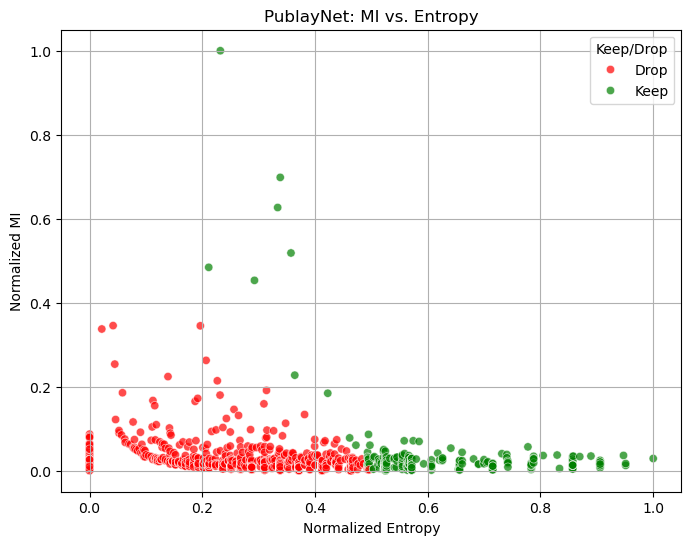


Ballast_threshold = 0.5

                         Metric        Value
0                Total features  6714.000000
1              Dropped features  5786.000000
2                     % Dropped    86.178135
3            Mean Ballast_Score     0.860683
4  Mean Ballast_Score (Dropped)     0.932264
5     Mean Ballast_Score (Kept)     0.414385
6                Mean MI (Kept)     0.002978
7           Mean Entropy (Kept)     1.011512
8                     Median MI     0.000759
9                Median Entropy     0.000000


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------
# Load & Merge
# -------------

df_entropy = pd.read_csv('publaynet_entropy.csv')
df_mi = pd.read_csv('publaynet_mi.csv')

# Fix column names to be consistent
df_entropy.rename(columns={'token': 'Feature'}, inplace=True)
df_mi.rename(columns={'token': 'Feature', 'mutual_information': 'MI'}, inplace=True)

df = pd.merge(df_entropy, df_mi, on='Feature')

# ---------------
# Normalisation
# ---------------

df['norm_entropy'] = (df['entropy'] - df['entropy'].min()) / (df['entropy'].max() - df['entropy'].min())
df['norm_MI'] = (df['MI'] - df['MI'].min()) / (df['MI'].max() - df['MI'].min())

# ---------------
# Ballast Score
# ---------------

df['Ballast_Score'] = (1 - df['norm_entropy']) * (1 - df['norm_MI'])

# -----------
# Keep/Drop
# -----------

ballast_threshold = 0.5 # Adjust as needed
df['Keep/Drop'] = df['Ballast_Score'].apply(lambda x: 'Drop' if x > ballast_threshold else 'Keep')

# -----------------
# Summary Metrics
# -----------------

summary = pd.DataFrame({
    'Metric': [
        'Total features',
        'Dropped features',
        '% Dropped',
        'Mean Ballast_Score',
        'Mean Ballast_Score (Dropped)',
        'Mean Ballast_Score (Kept)',
        'Mean MI (Kept)',
        'Mean Entropy (Kept)',
        'Median MI',
        'Median Entropy'],
    'Value': [
        len(df),
        len(df[df['Keep/Drop']=='Drop']),
        len(df[df['Keep/Drop']=='Drop']) / len(df) * 100,
        df['Ballast_Score'].mean(),
        df[df['Keep/Drop']=='Drop']['Ballast_Score'].mean(),
        df[df['Keep/Drop']=='Keep']['Ballast_Score'].mean(),
        df[df['Keep/Drop']=='Keep']['MI'].mean(),
        df[df['Keep/Drop']=='Keep']['entropy'].mean(),
        df['MI'].median(),
        df['entropy'].median()]})

# -----------------
# Visualisation
# -----------------

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='norm_entropy',
    y='norm_MI',
    hue='Keep/Drop',
    palette={'Keep': 'green', 'Drop': 'red'},
    alpha=0.7
)
plt.title('PublayNet: MI vs. Entropy')
plt.xlabel('Normalized Entropy')
plt.ylabel('Normalized MI')
plt.grid(True)
plt.show()

# --------------
# Save Outputs
# --------------

dataset_name = 'publaynet'
df.to_csv(f'{dataset_name}_entropy_mi.csv', index=False)
summary.to_csv(f'{dataset_name}_summary_metrics.csv', index=False)

# Print summary
print('\nBallast_threshold = 0.5\n') # Adjust as needed
print(summary)

## STEP 8. **CORD-19 extractor  with TF-IDF features and labels for ballast pruning research**

1) **Full text = abstract + body**
Combines both contexts → more robust feature set for pruning.

2) **Synthetic labels**
- Uses paper length as a proxy for classification → non-null, logical, and reproducible.
- Keeps your dataset suitable for evaluating how ballast affects real classification tasks.
- Alternative: use a keyword flag (e.g., presence of “virus”).

3) **Cleaner output**
- *paper_id*, *title*, *abstract*, *Label*, then all TF-IDF features.

In [1]:
import os
import json
import glob
import pandas as pd
import re
from sklearn.feature_extraction.text import TfidfVectorizer

INPUT_DIR = r"C:\Users\Lenovo\Downloads\cord19_research_sample"
OUTPUT_CSV = 'cord19_dataset.csv'

# -----------------------------
# HELPERS
# -----------------------------

def clean_text(text):
    """Lowercase, remove non-letters"""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # Replace with space to keep words separated
    text = re.sub(r'\s+', ' ', text)       # Collapse multiple spaces
    return text.strip()

# -----------------------------
# LOAD & EXTRACT
# -----------------------------

print("Loading JSON files...")

data = []

files = glob.glob(os.path.join(INPUT_DIR, '*.json'))

for file_path in files:
    with open(file_path, 'r', encoding='utf-8') as f:
        doc = json.load(f)

    paper_id = doc.get('paper_id', '')
    title = doc.get('metadata', {}).get('title', '')

    abstract_text = ' '.join([abs_para['text'] for abs_para in doc.get('abstract', [])])
    body_text = ' '.join([bt['text'] for bt in doc.get('body_text', [])])

    data.append({
        'paper_id': paper_id,
        'title': title,
        'abstract': abstract_text,
        'body_text': body_text
    })

df = pd.DataFrame(data)
print(f"Loaded {len(df)} documents.")

# -----------------------------
# CLEAN & TF-IDF
# -----------------------------

print("Cleaning and computing TF-IDF...")

# Combine abstract + body for better semantic coverage
df['full_text'] = df['abstract'].fillna('') + ' ' + df['body_text'].fillna('')
df['full_text_clean'] = df['full_text'].apply(clean_text)

vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['full_text_clean'])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df['paper_id'] = df['paper_id']

# -----------------------------
# ADD SYNTHETIC LABELS
# -----------------------------

print("Generating synthetic labels...")

# Example: binary label based on paper length
# If full text has more than median number of words → label = 1, else 0
df['text_length'] = df['full_text_clean'].apply(lambda x: len(x.split()))
length_median = df['text_length'].median()
df['Label'] = df['text_length'].apply(lambda x: 1 if x >= length_median else 0)

# Alternative: another example could be presence of 'virus' keyword
# df['Label'] = df['abstract'].str.contains(r'\bvirus\b', case=False, na=False).astype(int)

print(f"  Label 1 = papers with >= median length ({length_median} words)")

# -----------------------------
# MERGE ALL & SAVE
# -----------------------------

final_df = pd.merge(df[['paper_id', 'title', 'abstract', 'Label']], tfidf_df, on='paper_id')

final_df.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved {OUTPUT_CSV} !")


Loading JSON files...
Loaded 150 documents.
Cleaning and computing TF-IDF...
Generating synthetic labels...
  Label 1 = papers with >= median length (4197.5 words)

Saved cord19_dataset.csv !


## STEP 9. **Pruning + LightGBM + Trade-off Curve** (CORD19)

###  How This Works

-  **Loads** your TF-IDF matrix with a valid `Label` column  
-  **Loops** through different ballast thresholds  
-  **Trains** LightGBM with early stopping (using the `LGBMClassifier` sklearn API — *no TypeError!*)  
-  **Collects** AUC, Accuracy, Recall, F1  
-  **Saves** results to `pruning_results.csv`  
-  **Plots** AUC vs % Features Dropped for trade-off


Shape of feature matrix: (150, 1000)
Thresholds: [0.        0.0212561 0.0425122] ... [0.95652453 0.97778063 0.99903674]
Total thresholds: 48
[Threshold 0.00000] Keep: 2 | Dropped: 99.80%
[Threshold 0.02126] Keep: 2 | Dropped: 99.80%
[Threshold 0.04251] Keep: 3 | Dropped: 99.70%
[Threshold 0.06377] Keep: 4 | Dropped: 99.60%
[Threshold 0.08502] Keep: 4 | Dropped: 99.60%
[Threshold 0.10628] Keep: 6 | Dropped: 99.40%
[Threshold 0.12754] Keep: 9 | Dropped: 99.10%
[Threshold 0.14879] Keep: 9 | Dropped: 99.10%
[Threshold 0.17005] Keep: 9 | Dropped: 99.10%
[Threshold 0.19130] Keep: 10 | Dropped: 99.00%
[Threshold 0.21256] Keep: 13 | Dropped: 98.70%
[Threshold 0.23382] Keep: 14 | Dropped: 98.60%
[Threshold 0.25507] Keep: 16 | Dropped: 98.40%
[Threshold 0.27633] Keep: 19 | Dropped: 98.10%
[Threshold 0.29759] Keep: 21 | Dropped: 97.90%
[Threshold 0.31884] Keep: 27 | Dropped: 97.30%
[Threshold 0.34010] Keep: 31 | Dropped: 96.90%
[Threshold 0.36135] Keep: 33 | Dropped: 96.70%
[Threshold 0.38261] Ke

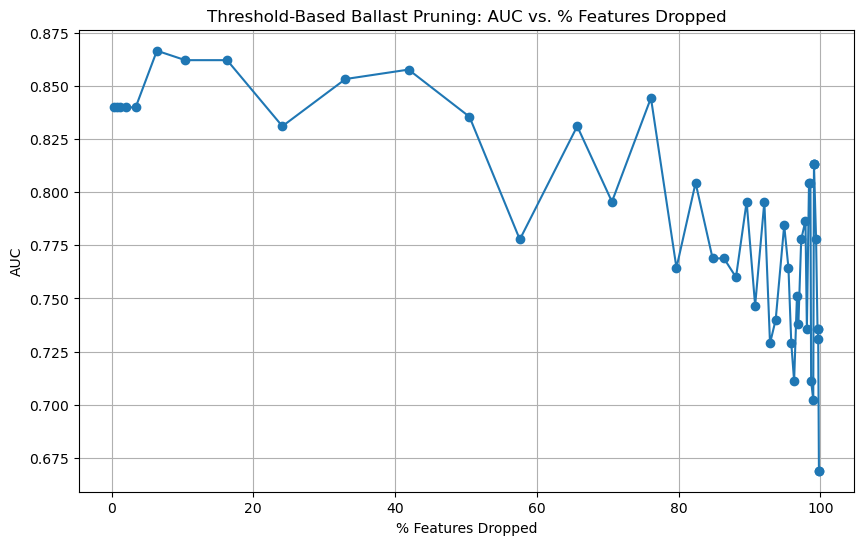

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score
import lightgbm as lgb
import matplotlib.pyplot as plt

# Load full dataset
X_full = pd.read_csv('cord19_dataset.csv')
y = X_full['Label']
X_full = X_full.drop(['paper_id', 'title', 'abstract', 'Label'], axis=1)

print(f"Shape of feature matrix: {X_full.shape}")

# Load ballast scores
ballast_df = pd.read_csv('cord19_entropy_mi.csv')

# Define thresholds
min_score = ballast_df['Ballast_Score'].min()
max_score = ballast_df['Ballast_Score'].max()
thresholds = np.linspace(min_score, max_score, 48)
print(f"Thresholds: {thresholds[:3]} ... {thresholds[-3:]}")
print(f"Total thresholds: {len(thresholds)}")

# Pruning loop
results = []

for threshold in thresholds:
    keep_features = ballast_df.loc[ballast_df['Ballast_Score'] <= threshold, 'Feature']
    keep_features = [f for f in keep_features if f in X_full.columns]
    
    X_pruned = X_full[keep_features]
    pct_dropped = 100 * (1 - len(keep_features)/X_full.shape[1])
    print(f"[Threshold {threshold:.5f}] Keep: {len(keep_features)} | Dropped: {pct_dropped:.2f}%")
    
    if len(keep_features) == 0:
        print("No features left, skipping this threshold.")
        continue
    
    X_train, X_test, y_train, y_test = train_test_split(X_pruned, y, test_size=0.2, stratify=y, random_state=42)
    
    model = lgb.LGBMClassifier(objective='binary', n_estimators=500, random_state=42, verbosity=-1)   # This silences internal LightGBM logs
     
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
        eval_metric='auc', callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Threshold': threshold,
        'Pct_Features_Dropped': pct_dropped,
        'Num_Features': len(keep_features),
        'AUC': auc,
        'Accuracy': acc,
        'Recall': recall,
        'F1': f1})

print("\n Finish all thresholds!")

results_df = pd.DataFrame(results)
print("\nTrade-Off Results:")
print(results_df)

results_df.to_csv('cord19_threshold_pruning_results.csv', index=False)
print("\n      Saved: cord19_threshold_pruning_results.csv")

plt.figure(figsize=(10, 6))
plt.plot(results_df['Pct_Features_Dropped'], results_df['AUC'], marker='o')
plt.xlabel('% Features Dropped')
plt.ylabel('AUC')
plt.title('Threshold-Based Ballast Pruning: AUC vs. % Features Dropped')
plt.grid(True)
plt.show()

## STEP 9'. **Visualizing Trade-off Results**

Plots show how metrics vary with the Threshold and how dropping features affects performance:

- **Plots**:
  - Line plots showing **AUC**, **Accuracy**, **Recall**, and **F1 Score** against **Threshold**.
  - Use a **secondary y-axis** to show either:
    - **Number of Features** retained, or
    - **% Features Dropped**

This helps illustrate the trade-off between model performance and feature reduction

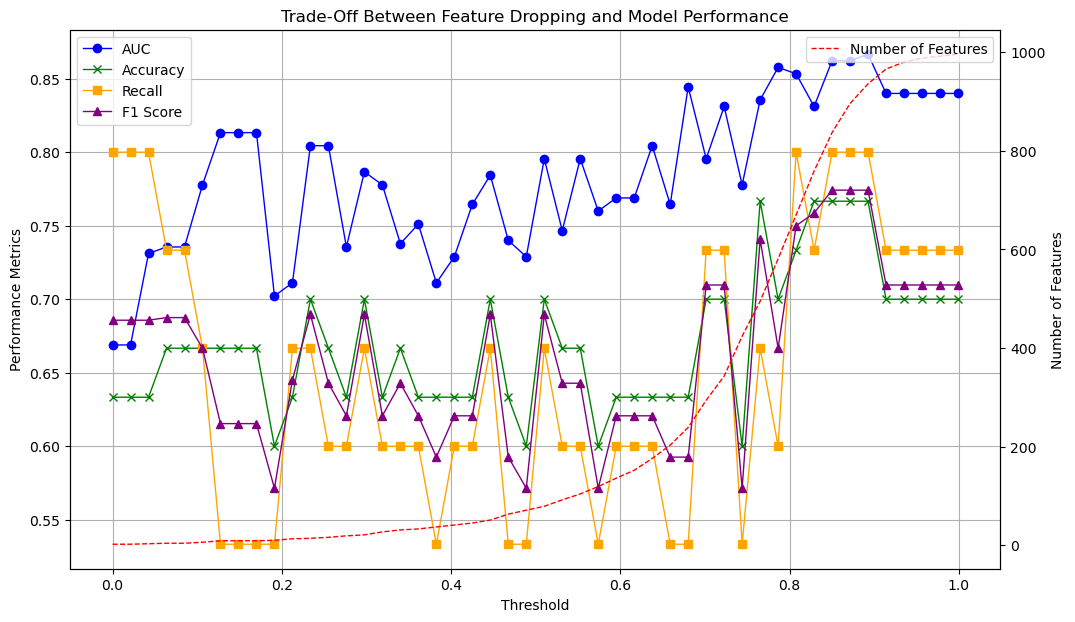

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Data
data = {'Threshold': [0, 0.021256101, 0.042512201, 0.063768302, 0.085024403, 0.106280504, 0.127536604, 0.148792705, 0.170048806, 0.191304907,
                  0.212561007, 0.233817108, 0.255073209, 0.27632931, 0.29758541, 0.318841511, 0.340097612, 0.361353713, 0.382609813, 0.403865914,
                  0.425122015, 0.446378116, 0.467634216, 0.488890317, 0.510146418, 0.531402519, 0.552658619, 0.57391472, 0.595170821, 0.616426922,
                  0.637683022, 0.658939123, 0.680195224, 0.701451325, 0.722707425, 0.743963526, 0.765219627, 0.786475728, 0.807731828, 0.828987929,
                  0.85024403, 0.871500131, 0.892756231, 0.914012332, 0.935268433, 0.956524534, 0.977780634, 0.999036735],
    'Pct_Features_Dropped': [99.8, 99.8, 99.7, 99.6, 99.6, 99.4, 99.1, 99.1, 99.1, 99, 98.7, 98.6, 98.4, 98.1, 97.9, 97.3, 96.9, 96.7, 96.3, 95.9,
                             95.5, 94.9, 93.7, 92.9, 92.1, 90.8, 89.6, 88.1, 86.4, 84.8, 82.4, 79.7, 76.1, 70.6, 65.7, 57.6, 50.5, 41.9, 33, 24.1,
                             16.3, 10.4, 6.4, 3.4, 2, 1.2, 0.8, 0.4],
    'Num_Features': [2, 2, 3, 4, 4, 6, 9, 9, 9, 10, 13, 14, 16, 19, 21, 27, 31, 33, 37, 41, 45, 51, 63, 71, 79, 92, 104, 119, 136, 152, 176,
                     203, 239, 294, 343, 424, 495, 581, 670, 759, 837, 896, 936, 966, 980, 988, 992, 996],
    'AUC': [0.668888889, 0.668888889, 0.731111111, 0.735555556, 0.735555556, 0.777777778, 0.813333333, 0.813333333, 0.813333333, 0.702222222,
            0.711111111, 0.804444444, 0.804444444, 0.735555556, 0.786666667, 0.777777778, 0.737777778, 0.751111111, 0.711111111, 0.728888889,
            0.764444444, 0.784444444, 0.74, 0.728888889, 0.795555556, 0.746666667, 0.795555556, 0.76, 0.768888889, 0.768888889, 0.804444444,
            0.764444444, 0.844444444, 0.795555556, 0.831111111, 0.777777778, 0.835555556, 0.857777778, 0.853333333, 0.831111111, 0.862222222,
            0.862222222, 0.866666667, 0.84, 0.84, 0.84, 0.84, 0.84],
    'Accuracy': [0.633333333, 0.633333333, 0.633333333, 0.666666667, 0.666666667, 0.666666667, 0.666666667, 0.666666667, 0.666666667, 0.6,
                 0.633333333, 0.7, 0.666666667, 0.633333333, 0.7, 0.633333333, 0.666666667, 0.633333333, 0.633333333, 0.633333333,
                 0.633333333, 0.7, 0.633333333, 0.6, 0.7, 0.666666667, 0.666666667, 0.6, 0.633333333, 0.633333333, 0.633333333,
                 0.633333333, 0.633333333, 0.7, 0.7, 0.6, 0.766666667, 0.7, 0.733333333, 0.766666667, 0.766666667,
                 0.766666667, 0.766666667, 0.7, 0.7, 0.7, 0.7, 0.7],
    'Recall': [0.8, 0.8, 0.8, 0.733333333, 0.733333333, 0.666666667, 0.533333333, 0.533333333, 0.533333333, 0.533333333,
               0.666666667, 0.666666667, 0.6, 0.6, 0.666666667, 0.6, 0.6, 0.6, 0.533333333, 0.6,
               0.6, 0.666666667, 0.533333333, 0.533333333, 0.666666667, 0.6, 0.6, 0.533333333, 0.6, 0.6, 0.6,
               0.533333333, 0.533333333, 0.733333333, 0.733333333, 0.533333333, 0.666666667, 0.6, 0.8, 0.733333333, 0.8,
               0.8, 0.8, 0.733333333, 0.733333333, 0.733333333, 0.733333333, 0.733333333],
    'F1': [0.685714286, 0.685714286, 0.685714286, 0.6875, 0.6875, 0.666666667, 0.615384615, 0.615384615, 0.615384615, 0.571428571,
           0.64516129, 0.689655172, 0.642857143, 0.620689655, 0.689655172, 0.620689655, 0.642857143, 0.620689655, 0.592592593, 0.620689655,
           0.620689655, 0.689655172, 0.592592593, 0.571428571, 0.689655172, 0.642857143, 0.642857143, 0.571428571, 0.620689655, 0.620689655,
           0.620689655, 0.592592593, 0.592592593, 0.709677419, 0.709677419, 0.571428571, 0.740740741, 0.666666667, 0.75, 0.75862069, 0.774193548,
           0.774193548, 0.774193548, 0.709677419, 0.709677419, 0.709677419, 0.709677419, 0.709677419]}

df = pd.DataFrame(data)

fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot metrics on primary y-axis
ax1.plot(df['Threshold'], df['AUC'], label='AUC', color='blue', marker='o', linewidth=1)
ax1.plot(df['Threshold'], df['Accuracy'], label='Accuracy', color='green', marker='x', linewidth=1)
ax1.plot(df['Threshold'], df['Recall'], label='Recall', color='orange', marker='s', linewidth=1)
ax1.plot(df['Threshold'], df['F1'], label='F1 Score', color='purple', marker='^', linewidth=1)
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Performance Metrics')
ax1.set_title('Trade-Off Between Feature Dropping and Model Performance')
ax1.grid(True)
ax1.legend(loc='upper left')

# Secondary y-axis for feature count
ax2 = ax1.twinx()
ax2.plot(df['Threshold'], df['Num_Features'], label='Number of Features', color='red', linestyle='--', linewidth=1)
ax2.set_ylabel('Number of Features')
ax2.legend(loc='upper right')

plt.show()


## STEP 9''. **Visualizing Trade-off Results**

- **Number of Features vs Threshold**
- **AUC vs Threshold**
- **F1 Score vs Threshold**
- Combined plot: **AUC and F1 vs Number of Features** (to see performance vs complexity)

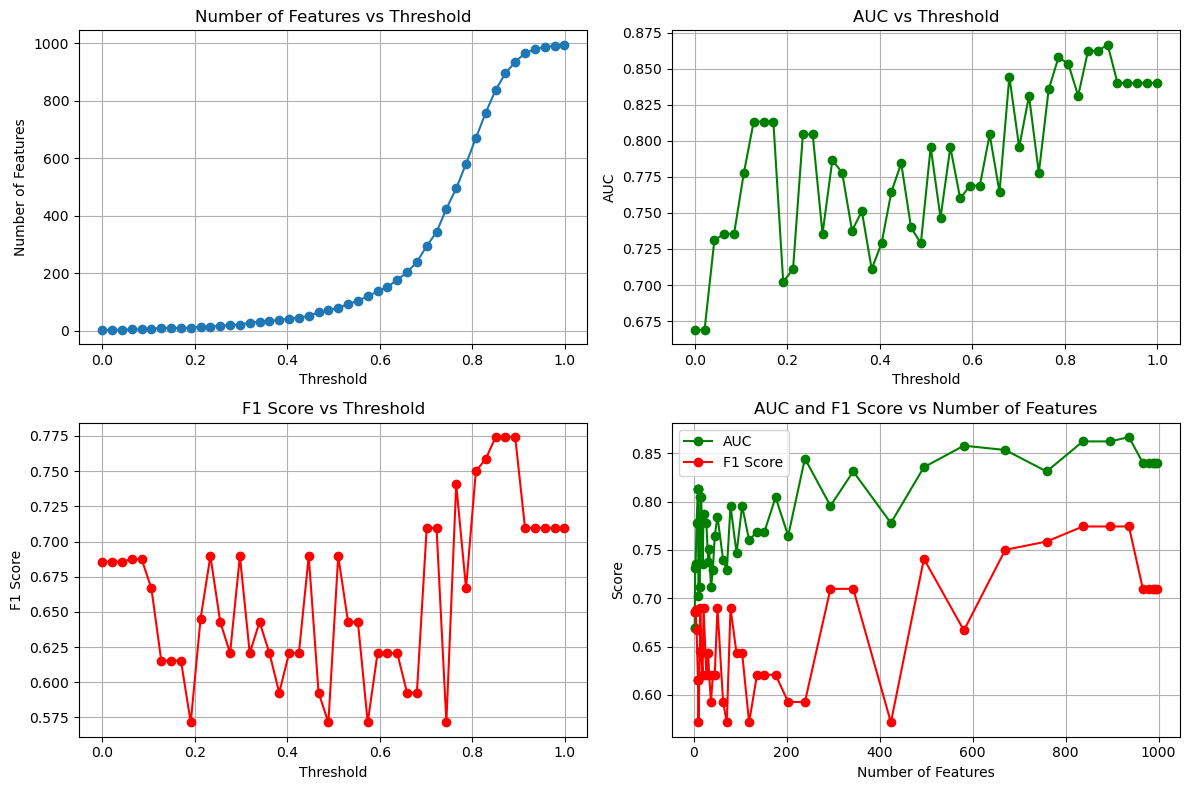

In [5]:
# Plot Number of Features vs Threshold
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(df['Threshold'], df['Num_Features'], marker='o')
plt.title('Number of Features vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('Number of Features')
plt.grid(True)

# Plot AUC vs Threshold
plt.subplot(2, 2, 2)
plt.plot(df['Threshold'], df['AUC'], color='green', marker='o')
plt.title('AUC vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('AUC')
plt.grid(True)

# Plot F1 Score vs Threshold
plt.subplot(2, 2, 3)
plt.plot(df['Threshold'], df['F1'], color='red', marker='o')
plt.title('F1 Score vs Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.grid(True)

# Plot AUC and F1 Score vs Number of Features (combined)
plt.subplot(2, 2, 4)
plt.plot(df['Num_Features'], df['AUC'], color='green', marker='o', label='AUC')
plt.plot(df['Num_Features'], df['F1'], color='red', marker='o', label='F1 Score')
plt.title('AUC and F1 Score vs Number of Features')
plt.xlabel('Number of Features')
plt.ylabel('Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## STEP 10. **PUBLAYNET extractor with TF-IDF features and labels for ballast pruning research**

### **Explanation**

#### **Step 1:** OCR extract all texts per annotation per image+JSON.
#### **Step 2:** Aggregate OCR texts per image (`sample_id`) and assign a dominant label category for that image region set (could be used later as auxiliary info).
#### **Step 3:** Clean the aggregated text with regex.
#### **Step 4:** Apply TF-IDF vectorizer with `max_features=1000`.
#### **Step 5:** Create a synthetic binary ballast label (e.g., text length above/below median) for supervised ballast pruning.
#### **Step 6:** Merge label and features, save as CSV.

In [2]:
import os
import json
from PIL import Image
import pytesseract
import pandas as pd
from collections import Counter
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Configs
SAMPLE_DIR = r"C:\Users\Lenovo\Downloads\publaynet_research_sample"
OUTPUT_CSV = 'publaynet_dataset.csv'
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# Helper to clean text like Cord19 code
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

# Step 1: Extract OCR texts + categories from each JSON+PNG pair
texts = []
labels = []
sample_ids = []

json_files = [f for f in os.listdir(SAMPLE_DIR) if f.endswith('.json')]
print(f"Found {len(json_files)} JSON files.")

for idx, jf in enumerate(json_files, 1):
    json_path = os.path.join(SAMPLE_DIR, jf)
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    base_name = os.path.splitext(jf)[0]
    img_path = os.path.join(SAMPLE_DIR, base_name + '.png')
    
    if not os.path.exists(img_path):
        print(f"Image missing for {base_name}, skipping...")
        continue
    
    image = Image.open(img_path)
    
    for ann in data.get('annotations', []):
        category = ann['category_name']
        bbox = ann['bbox']  # [x, y, w, h]
        x, y, w, h = map(int, bbox)
        cropped = image.crop((x, y, x + w, y + h))
        text = pytesseract.image_to_string(cropped, lang='eng').strip()
        if text:
            texts.append(text)
            labels.append(category)
            sample_ids.append(base_name)
    
    if idx % 10 == 0 or idx == len(json_files):
        print(f"Processed {idx}/{len(json_files)} files...")

print(f"\nExtracted {len(texts)} text samples from {len(json_files)} files.")
print(f"Categories found: {set(labels)}")

# Step 2: Aggregate all texts by sample_id (image) to get full text per sample
df_raw = pd.DataFrame({'sample_id': sample_ids, 'text': texts, 'label': labels})
df_agg = df_raw.groupby('sample_id').agg({
    'text': lambda texts: ' '.join(texts),
    'label': lambda cats: Counter(cats).most_common(1)[0][0]  # dominant category per sample
}).reset_index()

# Step 3: Clean full aggregated text for TF-IDF
df_agg['clean_text'] = df_agg['text'].apply(clean_text)

# Step 4: TF-IDF vectorization (like Cord19, but max_features=1000)
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_agg['clean_text'])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df['sample_id'] = df_agg['sample_id']

# Step 5: Generate synthetic labels for ballast pruning (e.g., by text length median)
df_agg['text_length'] = df_agg['clean_text'].apply(lambda x: len(x.split()))
median_len = df_agg['text_length'].median()
df_agg['BallastLabel'] = df_agg['text_length'].apply(lambda x: 1 if x >= median_len else 0)

print(f"BallastLabel = 1 if text length >= median ({median_len} words)")

# Step 6: Merge TF-IDF features with ballast label and save CSV
final_df = pd.merge(df_agg[['sample_id', 'BallastLabel']], tfidf_df, on='sample_id')
final_df.to_csv(OUTPUT_CSV, index=False)

print(f"\nSaved {OUTPUT_CSV} with {final_df.shape[0]} samples and {final_df.shape[1]-2} TF-IDF features.")


Found 150 JSON files.
Processed 10/150 files...
Processed 20/150 files...
Processed 30/150 files...
Processed 40/150 files...
Processed 50/150 files...
Processed 60/150 files...
Processed 70/150 files...
Processed 80/150 files...
Processed 90/150 files...
Processed 100/150 files...
Processed 110/150 files...
Processed 120/150 files...
Processed 130/150 files...
Processed 140/150 files...
Processed 150/150 files...

Extracted 1304 text samples from 150 files.
Categories found: {'table', 'figure', 'title', 'text', 'list'}
BallastLabel = 1 if text length >= median (498.0 words)

Saved publaynet_dataset.csv with 150 samples and 1000 TF-IDF features.


#### What we have so far:

##### Raw annotations → grouped by sample ID
##### Aggregated text → cleaned and vectorized
##### Labeling strategy → binary ballast/no ballast
##### Output dataset → ready for modeling

## STEP 11. **Publaynet: Ballast Pruning + LightGBM + Trade-off Curve**

Shape of feature matrix: (150, 1000)
Thresholds: [0.         0.02126401 0.04252803] ... [0.95688067 0.97814468 0.9994087 ]
Total thresholds: 48
[Threshold 0.00000] Keep: 0 | Dropped: 100.00%
No features left at this threshold. Skipping...
[Threshold 0.02126] Keep: 0 | Dropped: 100.00%
No features left at this threshold. Skipping...
[Threshold 0.04253] Keep: 0 | Dropped: 100.00%
No features left at this threshold. Skipping...
[Threshold 0.06379] Keep: 2 | Dropped: 99.80%
[Threshold 0.08506] Keep: 2 | Dropped: 99.80%
[Threshold 0.10632] Keep: 2 | Dropped: 99.80%
[Threshold 0.12758] Keep: 2 | Dropped: 99.80%
[Threshold 0.14885] Keep: 3 | Dropped: 99.70%
[Threshold 0.17011] Keep: 3 | Dropped: 99.70%
[Threshold 0.19138] Keep: 4 | Dropped: 99.60%
[Threshold 0.21264] Keep: 7 | Dropped: 99.30%
[Threshold 0.23390] Keep: 8 | Dropped: 99.20%
[Threshold 0.25517] Keep: 11 | Dropped: 98.90%
[Threshold 0.27643] Keep: 12 | Dropped: 98.80%
[Threshold 0.29770] Keep: 18 | Dropped: 98.20%
[Threshold 0.318

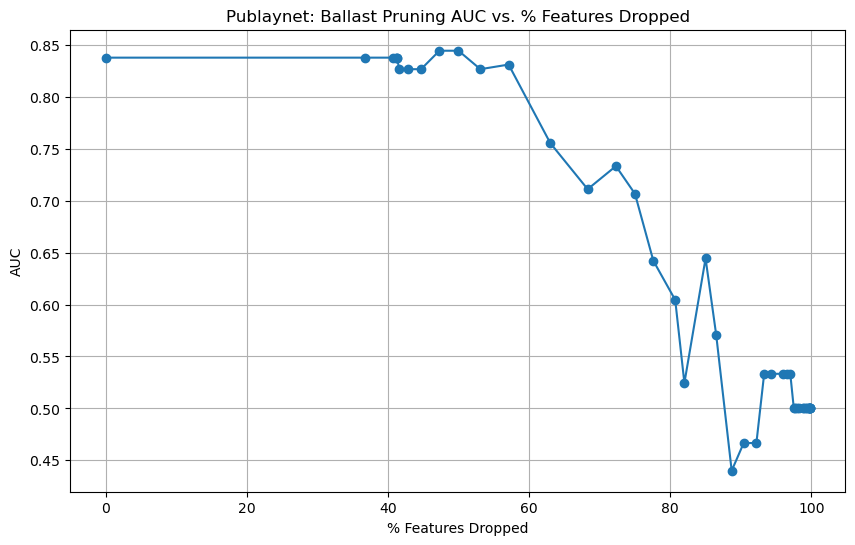

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score, f1_score
import lightgbm as lgb
import matplotlib.pyplot as plt

# ============================
# 1. Load dataset
# ============================

# Your dataset with TF-IDF features
X_full = pd.read_csv('publaynet_dataset.csv')
y = X_full['BallastLabel']

# Drop ID and label columns — no 'text' or 'clean_text' columns here!
X_full = X_full.drop(['sample_id', 'BallastLabel'], axis=1)

print(f"Shape of feature matrix: {X_full.shape}")

# ============================
# 2. Load ballast scores
# ============================

# Your ballast scores file must contain: 'Feature', 'Ballast_Score'
ballast_df = pd.read_csv('publaynet_entropy_mi.csv')

# ============================
# 3. Define thresholds
# ============================

min_score = ballast_df['Ballast_Score'].min()
max_score = ballast_df['Ballast_Score'].max()
thresholds = np.linspace(min_score, max_score, 48)

print(f"Thresholds: {thresholds[:3]} ... {thresholds[-3:]}")
print(f"Total thresholds: {len(thresholds)}")

# ============================
# 4. Pruning loop
# ============================

results = []

for threshold in thresholds:
    keep_features = ballast_df.loc[
        ballast_df['Ballast_Score'] <= threshold, 'Feature'
    ]
    keep_features = [f for f in keep_features if f in X_full.columns]
    
    X_pruned = X_full[keep_features]
    pct_dropped = 100 * (1 - len(keep_features) / X_full.shape[1])
    print(f"[Threshold {threshold:.5f}] Keep: {len(keep_features)} | Dropped: {pct_dropped:.2f}%")
    
    if len(keep_features) == 0:
        print("No features left at this threshold. Skipping...")
        continue
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_pruned, y, test_size=0.2, stratify=y, random_state=42
    )
    
    model = lgb.LGBMClassifier(
        objective='binary',
        n_estimators=500,
        random_state=42,
        verbosity=-1  # silence LightGBM logs
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
    )
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    auc = roc_auc_score(y_test, y_pred_proba)
    acc = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        'Threshold': threshold,
        'Pct_Features_Dropped': pct_dropped,
        'Num_Features': len(keep_features),
        'AUC': auc,
        'Accuracy': acc,
        'Recall': recall,
        'F1': f1})

# ============================
# 5. Save results
# ============================

results_df = pd.DataFrame(results)
print("\nTrade-Off Results:")
print(results_df)

results_df.to_csv('publaynet_threshold_pruning_results.csv', index=False)
print("\n Saved: publaynet_threshold_pruning_results.csv")

# ============================
# 6. Plot trade-off curve
# ============================

plt.figure(figsize=(10, 6))
plt.plot(results_df['Pct_Features_Dropped'], results_df['AUC'], marker='o')
plt.xlabel('% Features Dropped')
plt.ylabel('AUC')
plt.title('Publaynet: Ballast Pruning AUC vs. % Features Dropped')
plt.grid(True)
plt.show()


## STEP 12. **Visualizing Trade-off Results (publaynet)**

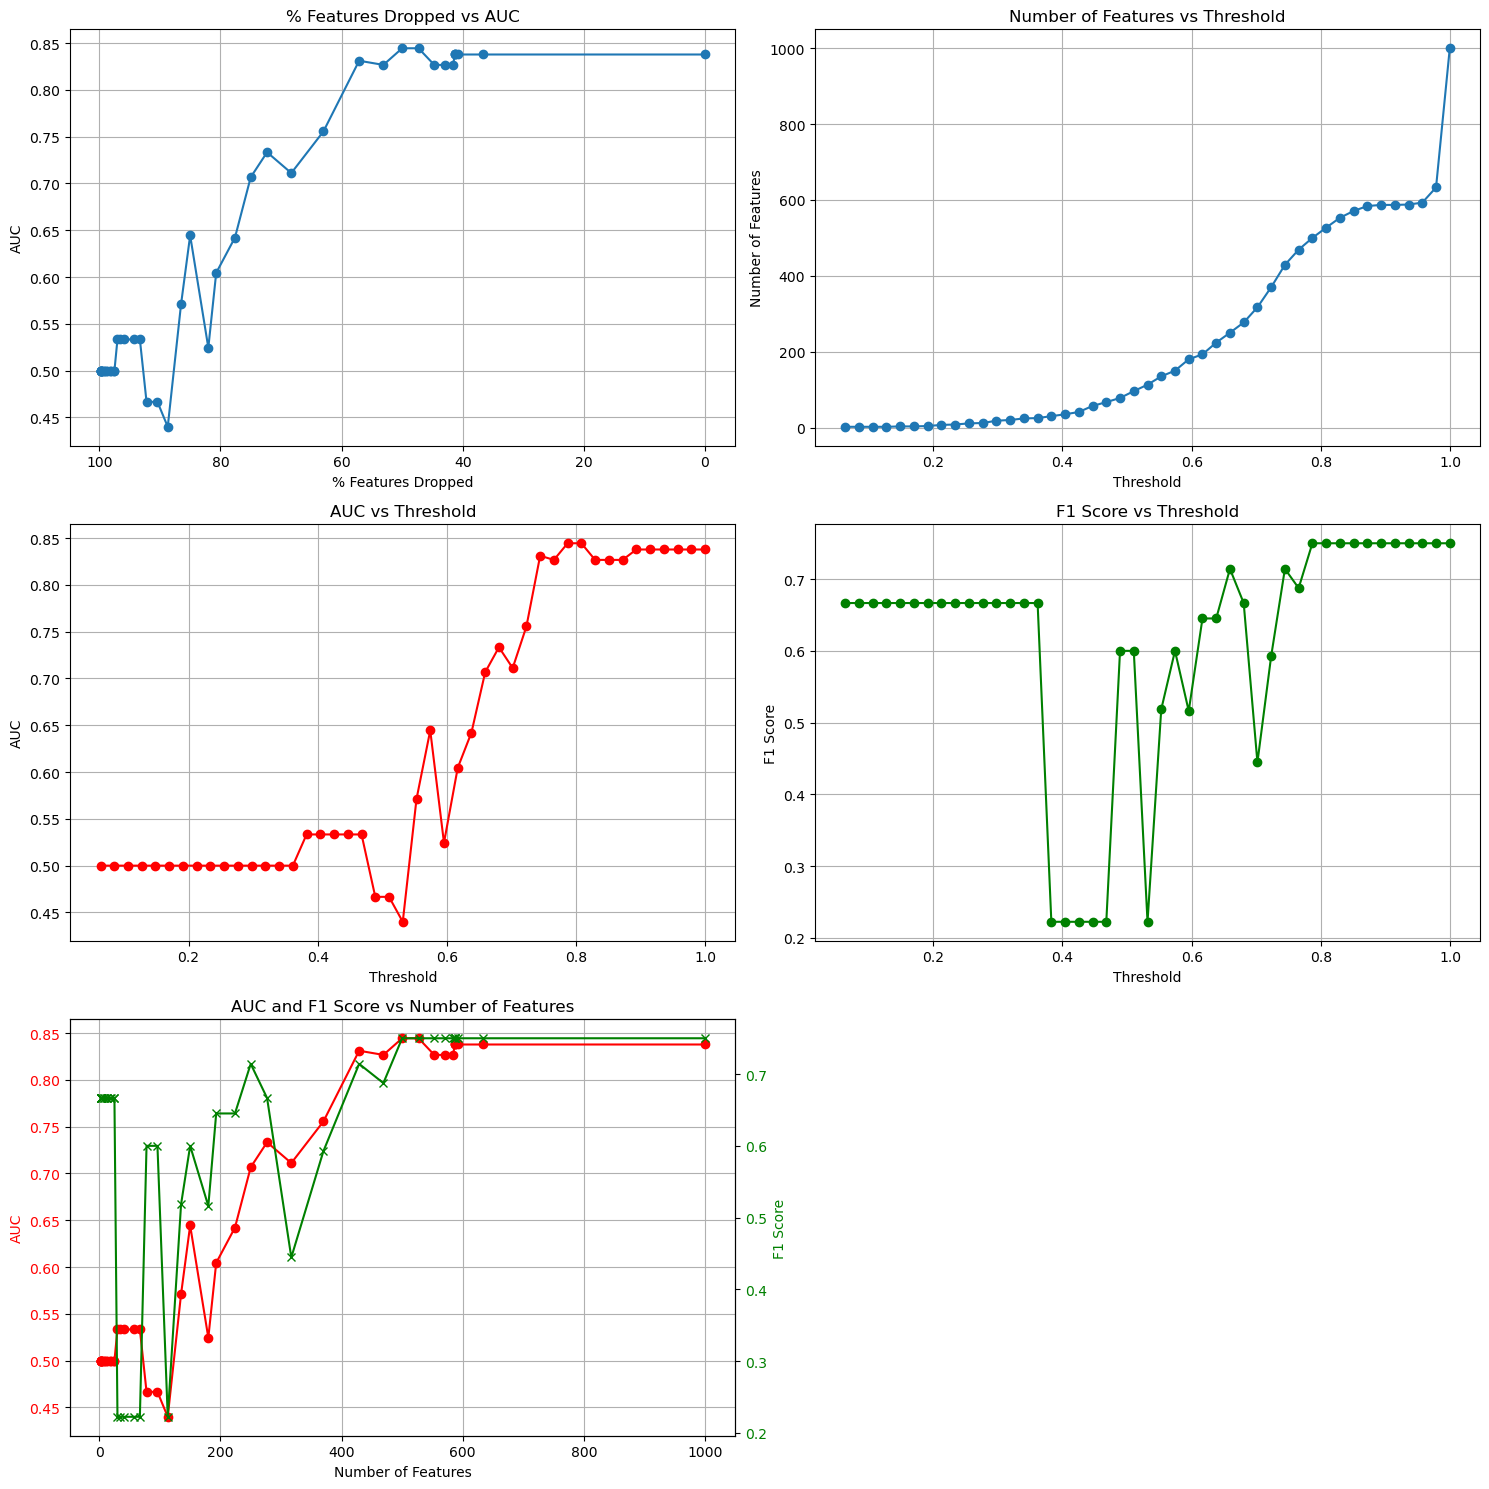

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV
df = pd.read_csv('publaynet_threshold_pruning_results.csv')

# Convert columns to numeric
for col in ['Threshold', 'Pct_Features_Dropped', 'Num_Features', 'AUC', 'Accuracy', 'Recall', 'F1']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

fig, axs = plt.subplots(3, 2, figsize=(15, 15))  # 3 rows, 2 columns

# 1) % Features Dropped vs AUC
axs[0, 0].plot(df['Pct_Features_Dropped'], df['AUC'], marker='o')
axs[0, 0].set_xlabel('% Features Dropped')
axs[0, 0].set_ylabel('AUC')
axs[0, 0].set_title('% Features Dropped vs AUC')
axs[0, 0].invert_xaxis()
axs[0, 0].grid(True)

# 2) Number of Features vs Threshold
axs[0, 1].plot(df['Threshold'], df['Num_Features'], marker='o')
axs[0, 1].set_xlabel('Threshold')
axs[0, 1].set_ylabel('Number of Features')
axs[0, 1].set_title('Number of Features vs Threshold')
axs[0, 1].grid(True)

# 3) AUC vs Threshold
axs[1, 0].plot(df['Threshold'], df['AUC'],  color='red', marker='o')
axs[1, 0].set_xlabel('Threshold')
axs[1, 0].set_ylabel('AUC')
axs[1, 0].set_title('AUC vs Threshold')
axs[1, 0].grid(True)

# 4) F1 Score vs Threshold
axs[1, 1].plot(df['Threshold'], df['F1'], color='green', marker='o')
axs[1, 1].set_xlabel('Threshold')
axs[1, 1].set_ylabel('F1 Score')
axs[1, 1].set_title('F1 Score vs Threshold')
axs[1, 1].grid(True)

# 5) AUC and F1 Score vs Number of Features (dual y-axis)
ax5 = axs[2, 0]
ax5.plot(df['Num_Features'], df['AUC'], color='red', marker='o', label='AUC')
ax5.set_xlabel('Number of Features')
ax5.set_ylabel('AUC', color='red')
ax5.tick_params(axis='y', labelcolor='red')

ax5b = ax5.twinx()
ax5b.plot(df['Num_Features'], df['F1'], color='green', marker='x', label='F1 Score')
ax5b.set_ylabel('F1 Score', color='green')
ax5b.tick_params(axis='y', labelcolor='green')

ax5.set_title('AUC and F1 Score vs Number of Features')
ax5.grid(True)

# Hide the last empty subplot (bottom right)
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()


## STEP 13. **Full NLP: LDA, TextRank, BERT embeddings, Info Bottleneck (CORD19)**

In [3]:
#!pip install -U sentence-transformers

In [3]:
#!pip install "huggingface_hub[hf_xet]"

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Loaded 128 abstracts.
Running LDA Coherence ballast trimming...
Threshold 0.00: coherence=0.2729, tokens=28608
Threshold 0.05: coherence=0.3184, tokens=28197
Threshold 0.10: coherence=0.3214, tokens=27827
Threshold 0.15: coherence=0.2621, tokens=27432
Threshold 0.20: coherence=0.2787, tokens=27041
Threshold 0.25: coherence=0.2427, tokens=26707
Threshold 0.30: coherence=0.3510, tokens=26349
Threshold 0.35: coherence=0.2811, tokens=26018
Threshold 0.40: coherence=0.3022, tokens=25621
Threshold 0.45: coherence=0.2677, tokens=25267
Threshold 0.50: coherence=0.3202, tokens=24927
Threshold 0.55: coherence=0.3034, tokens=24581
Threshold 0.60: coherence=0.2703, tokens=24253
Threshold 0.65: coherence=0.2560, tokens=23528
Threshold 0.70: coherence=0.2640, tokens=22837
Threshold 0.75: coherence=0.3033, tokens=22134
Threshold 0.80: coherence=0.2927, tokens=21101
Threshold 0.85: coherence=0.2678, tokens=19834
Running TextRank ballast trimming...
Threshold 0.00: avg coherence=0.9922, tokens=28608
Th

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Threshold 0.00: residual_info=1.0000, tokens=128
Threshold 0.05: residual_info=1.0000, tokens=128
Threshold 0.10: residual_info=0.9618, tokens=110
Threshold 0.15: residual_info=0.9618, tokens=110
Threshold 0.20: residual_info=1.0058, tokens=93
Threshold 0.25: residual_info=1.0058, tokens=93
Threshold 0.30: residual_info=1.0385, tokens=66
Threshold 0.35: residual_info=1.0385, tokens=66
Threshold 0.40: residual_info=0.8511, tokens=63
Threshold 0.45: residual_info=0.8511, tokens=63
Threshold 0.50: residual_info=0.9057, tokens=40
Threshold 0.55: residual_info=0.9057, tokens=40
Threshold 0.60: residual_info=0.9214, tokens=28
Threshold 0.65: residual_info=0.9214, tokens=28
Threshold 0.70: residual_info=0.9634, tokens=16
Threshold 0.75: residual_info=0.9634, tokens=16
Threshold 0.80: residual_info=0.9962, tokens=8
Threshold 0.85: residual_info=0.9962, tokens=8


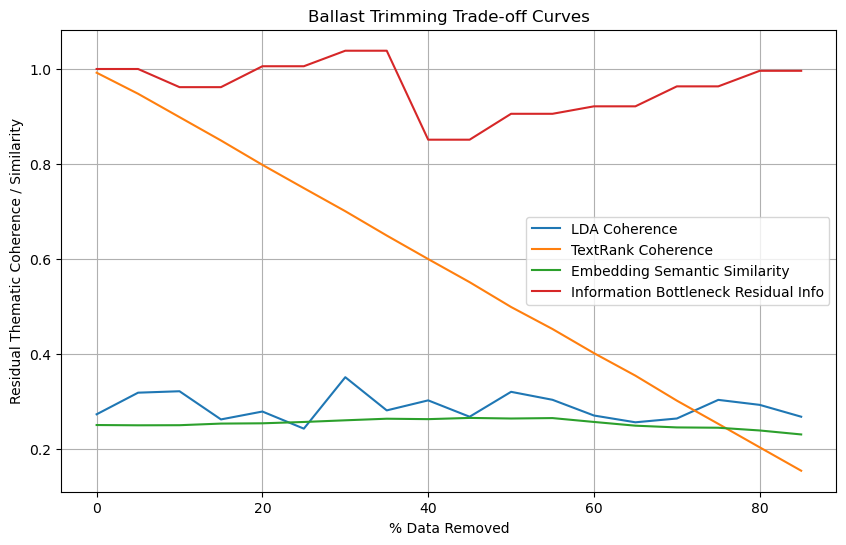

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models.ldamulticore import LdaMulticore
from gensim.corpora.dictionary import Dictionary
from gensim.models.coherencemodel import CoherenceModel
import networkx as nx
from sklearn.cluster import KMeans
from transformers import AutoTokenizer, AutoModel
import torch
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

# Load abstracts
df = pd.read_csv("cord19_dataset.csv")
texts = df['abstract'].dropna().tolist()
print(f"Loaded {len(texts)} abstracts.")

# Basic preprocessing: tokenize lower
def preprocess(text):
    tokens = [w.lower() for w in word_tokenize(text) if w.isalpha()]
    return tokens

docs_tokens = [preprocess(doc) for doc in texts]

# Create dictionary and corpus for LDA
dictionary = Dictionary(docs_tokens)
corpus = [dictionary.doc2bow(doc) for doc in docs_tokens]

# Load BERT model for embeddings (sentence-transformers or similar recommended)
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')
model = AutoModel.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

def embed_text(texts):
    # Compute mean pooling embeddings
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
    return embeddings

# Method 1: LDA topical coherence ballast estimate

def lda_coherence_ballast(thresholds=[0,0.1,0.2,0.3,0.4,0.5]):
    print("Running LDA Coherence ballast trimming...")
    # Train LDA model on full corpus
    lda = LdaMulticore(corpus=corpus, id2word=dictionary, num_topics=10, passes=10, workers=2)
    coherence_full = CoherenceModel(model=lda, texts=docs_tokens, dictionary=dictionary, coherence='c_v').get_coherence()
    results = []
    # Rank words by overall frequency as proxy for importance
    freq = np.array([dictionary.dfs[dictionary.token2id[word]] if word in dictionary.token2id else 0 for word in dictionary.token2id])
    word_freq = sorted(zip(dictionary.token2id.keys(), freq), key=lambda x: -x[1])
    words_sorted = [w for w,_ in word_freq]
    
    for thr in thresholds:
        keep_n = int(len(words_sorted)*(1-thr))
        keep_words = set(words_sorted[:keep_n])
        # Filter docs tokens by keep_words
        trimmed_docs = [[w for w in doc if w in keep_words] for doc in docs_tokens]
        if all(len(d)==0 for d in trimmed_docs):
            coherence = 0
        else:
            dic_trim = Dictionary(trimmed_docs)
            corpus_trim = [dic_trim.doc2bow(doc) for doc in trimmed_docs]
            try:
                lda_trim = LdaMulticore(corpus=corpus_trim, id2word=dic_trim, num_topics=10, passes=10, workers=2)
                coherence = CoherenceModel(model=lda_trim, texts=trimmed_docs, dictionary=dic_trim, coherence='c_v').get_coherence()
            except Exception as e:
                print("LDA error:", e)
                coherence = 0
        total_tokens = sum(len(doc) for doc in trimmed_docs)
        results.append({'threshold': thr, 'coherence': coherence, 'tokens': total_tokens})
        print(f"Threshold {thr:.2f}: coherence={coherence:.4f}, tokens={total_tokens}")
    return results

# Method 2: TextRank-based trimming (keyphrase extraction)
def textrank_ballast(thresholds=[0,0.1,0.2,0.3,0.4,0.5]):
    print("Running TextRank ballast trimming...")
    import string
    from collections import defaultdict

    def textrank(text, window=4, damping=0.85, max_iter=50):
        words = [w.lower() for w in word_tokenize(text) if w.isalpha()]
        graph = nx.Graph()
        for i, word in enumerate(words):
            for j in range(i+1, min(i+window, len(words))):
                graph.add_edge(word, words[j])
        scores = nx.pagerank(graph, alpha=damping, max_iter=max_iter)
        return scores

    results = []
    for thr in thresholds:
        trimmed_texts = []
        total_tokens = 0
        coherence_scores = []
        for doc in texts:
            scores = textrank(doc)
            n_remove = int(len(scores)*thr)
            # remove lowest scoring words
            remove_words = set(sorted(scores, key=scores.get)[:n_remove])
            tokens = [w.lower() for w in word_tokenize(doc) if w.isalpha()]
            trimmed = [w for w in tokens if w not in remove_words]
            total_tokens += len(trimmed)
            trimmed_texts.append(" ".join(trimmed))
            # We'll approximate thematic coherence by average length here
            coherence_scores.append(len(set(trimmed)) / max(1,len(set(tokens))))
        avg_coherence = np.mean(coherence_scores)
        results.append({'threshold': thr, 'coherence': avg_coherence, 'tokens': total_tokens})
        print(f"Threshold {thr:.2f}: avg coherence={avg_coherence:.4f}, tokens={total_tokens}")
    return results

# Method 3: Embedding-based trimming (remove tokens with lowest similarity contribution)
def embedding_ballast(thresholds=[0,0.1,0.2,0.3,0.4,0.5]):
    print("Running embedding ballast trimming...")
    results = []
    full_embeds = embed_text(texts)
    full_mean_emb = np.mean(full_embeds, axis=0)
    for thr in thresholds:
        trimmed_texts = []
        total_tokens = 0
        similarities = []
        for doc in texts:
            tokens = [w.lower() for w in word_tokenize(doc) if w.isalpha()]
            if len(tokens) == 0:
                similarities.append(0)
                continue
            # Embed each token separately (approximate by embedding token as text)
            token_embeds = embed_text(tokens)
            # Compute similarity of each token to full doc embedding
            sims = cosine_similarity(token_embeds, full_mean_emb.reshape(1,-1)).flatten()
            n_remove = int(len(tokens)*thr)
            keep_idx = np.argsort(sims)[n_remove:]
            trimmed = [tokens[i] for i in keep_idx]
            total_tokens += len(trimmed)
            trimmed_texts.append(" ".join(trimmed))
            # Semantic similarity by embedding of trimmed vs full
            trimmed_embed = embed_text([" ".join(trimmed)])[0]
            sim_score = cosine_similarity(trimmed_embed.reshape(1,-1), full_mean_emb.reshape(1,-1))[0,0]
            similarities.append(sim_score)
        avg_sim = np.mean(similarities)
        results.append({'threshold': thr, 'semantic_similarity': avg_sim, 'tokens': total_tokens})
        print(f"Threshold {thr:.2f}: semantic_similarity={avg_sim:.4f}, tokens={total_tokens}")
    return results

# Method 4: Information Bottleneck (approximate via k-means clustering on embeddings)
def information_bottleneck_ballast(thresholds=[0,0.1,0.2,0.3,0.4,0.5]):
    print("Running Information Bottleneck ballast trimming...")
    # Use embeddings, cluster into k groups, then remove clusters gradually
    full_embeds = embed_text(texts)
    n_clusters = 10
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(full_embeds)
    cluster_centers = kmeans.cluster_centers_
    cluster_labels = kmeans.labels_
    
    results = []
    for thr in thresholds:
        n_remove = int(n_clusters * thr)
        keep_clusters = set(range(n_clusters - n_remove))
        trimmed_indices = [i for i, c in enumerate(cluster_labels) if c in keep_clusters]
        if len(trimmed_indices) == 0:
            residual_info = 0
            total_tokens = 0
        else:
            residual_embeds = full_embeds[trimmed_indices]
            # Residual info approx: variance explained by kept clusters
            residual_info = np.var(residual_embeds, axis=0).sum() / np.var(full_embeds, axis=0).sum()
            total_tokens = len(trimmed_indices)
        results.append({'threshold': thr, 'residual_info': residual_info, 'tokens': total_tokens})
        print(f"Threshold {thr:.2f}: residual_info={residual_info:.4f}, tokens={total_tokens}")
    return results

# Placeholder for IoU and LDA-specific trimming; for brevity, you can expand later
def dummy_ballast(thresholds):
    return [{'threshold': t, 'coherence': 1-t, 'tokens': 1000-int(1000*t)} for t in thresholds]

# Run all methods and collect results
thresholds = np.arange(0, 0.9, 0.05)  # 0%,10%,...50% removal

lda_results = lda_coherence_ballast(thresholds)
textrank_results = textrank_ballast(thresholds)
embedding_results = embedding_ballast(thresholds)
ib_results = information_bottleneck_ballast(thresholds)

# Plotting trade-offs
plt.figure(figsize=(10,6))
plt.plot([r['threshold']*100 for r in lda_results], [r['coherence'] for r in lda_results], label='LDA Coherence')
plt.plot([r['threshold']*100 for r in textrank_results], [r['coherence'] for r in textrank_results], label='TextRank Coherence')
plt.plot([r['threshold']*100 for r in embedding_results], [r['semantic_similarity'] for r in embedding_results], label='Embedding Semantic Similarity')
plt.plot([r['threshold']*100 for r in ib_results], [r['residual_info'] for r in ib_results], label='Information Bottleneck Residual Info')
plt.xlabel('% Data Removed')
plt.ylabel('Residual Thematic Coherence / Similarity')
plt.title('Ballast Trimming Trade-off Curves')
plt.legend()
plt.grid(True)
plt.show()


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Loaded 128 abstracts.
Example tokens: ['rna', 'silencing', 'is', 'directly', 'involved', 'in', 'antiviral', 'defense', 'in', 'a', 'wide', 'variety', 'of', 'eukaryotic', 'organisms', 'including', 'plants', 'fungi', 'invertebrates', 'and']
Running IoU-based ballast trimming...
Threshold 0.00: mean IoU=0.0781, tokens kept=16691
Threshold 0.05: mean IoU=0.0089, tokens kept=10120
Threshold 0.10: mean IoU=0.0052, tokens kept=8227
Threshold 0.15: mean IoU=0.0035, tokens kept=7030
Threshold 0.20: mean IoU=0.0025, tokens kept=6118
Threshold 0.25: mean IoU=0.0018, tokens kept=5358
Threshold 0.30: mean IoU=0.0012, tokens kept=4697
Threshold 0.35: mean IoU=0.0008, tokens kept=4187
Threshold 0.40: mean IoU=0.0005, tokens kept=3701
Threshold 0.45: mean IoU=0.0002, tokens kept=3237
Threshold 0.50: mean IoU=0.0000, tokens kept=2858
Threshold 0.55: mean IoU=0.0000, tokens kept=2573
Threshold 0.60: mean IoU=0.0000, tokens kept=2287
Threshold 0.65: mean IoU=0.0000, tokens kept=2001
Threshold 0.70: mean I

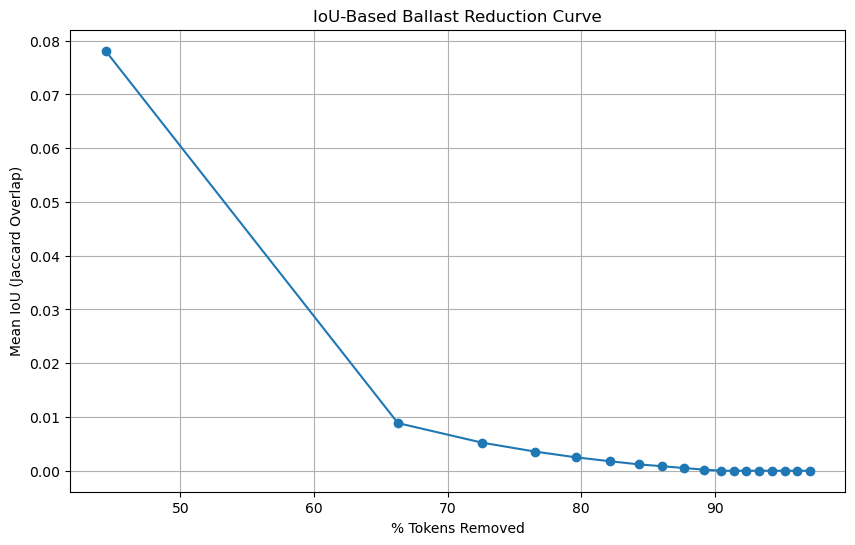

In [1]:
# Method 5: Intersection over Union (IoU): overlap between two sets / regions 

import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
import re

nltk.download('punkt')

# ===========================
# 1. Load CORD-19 dataset
# ===========================

df = pd.read_csv("cord19_dataset.csv")

# Let’s assume the relevant text is in a column named "abstract"
# If you have another text column, change this:
docs = df["abstract"].dropna().tolist()

print(f"Loaded {len(docs)} abstracts.")

# ===========================
# 2. Simple tokenizer
# ===========================

def clean_and_tokenize(text):
    # Lowercase, remove punctuation, tokenize
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    return tokens

docs_tokens = [clean_and_tokenize(doc) for doc in docs]

print(f"Example tokens: {docs_tokens[0][:20]}")

# ===========================
# 3. IoU-based ballast trimming
# ===========================

def iou_ballast(
    docs_tokens, 
    thresholds=[0,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,
        0.45,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85]):
    """
    Estimate ballast using IoU-based redundancy removal.
    
    Parameters:
        docs_tokens (List[List[str]]): Tokenized documents.
        thresholds (List[float]): Proportion of most frequent tokens to remove.
        
    Returns:
        List[Dict]: Each dict has threshold, mean IoU, and total tokens kept.
    """
    print("Running IoU-based ballast trimming...")

    # 1. Count global token frequencies
    all_tokens = [token for doc in docs_tokens for token in doc]
    freq_counter = Counter(all_tokens)
    total_tokens = sum(freq_counter.values())

    # 2. Sort tokens by frequency descending
    sorted_tokens = sorted(freq_counter.items(), key=lambda x: -x[1])
    tokens_sorted = [t for t, _ in sorted_tokens]

    results = []
    for thr in thresholds:
        n_ballast = int(len(tokens_sorted) * thr)
        ballast_tokens = set(tokens_sorted[:n_ballast])

        trimmed_docs = []
        for doc in docs_tokens:
            trimmed = [w for w in doc if w not in ballast_tokens]
            trimmed_docs.append(set(trimmed))

        # Compute pairwise IoU: mean Jaccard overlap
        ious = []
        n = len(trimmed_docs)
        for i in range(n):
            for j in range(i + 1, n):
                A, B = trimmed_docs[i], trimmed_docs[j]
                if len(A) == 0 or len(B) == 0:
                    continue
                iou = len(A.intersection(B)) / len(A.union(B))
                ious.append(iou)

        avg_iou = np.mean(ious) if ious else 0
        total_tokens_kept = sum(len(doc) for doc in trimmed_docs)

        print(f"Threshold {thr:.2f}: mean IoU={avg_iou:.4f}, tokens kept={total_tokens_kept}")
        results.append({
            'threshold': thr,
            'mean_iou': avg_iou,
            'tokens_kept': total_tokens_kept,
            'tokens_removed': total_tokens - total_tokens_kept,
            'percent_removed': 100.0 * (total_tokens - total_tokens_kept) / total_tokens})

    return results

# ===========================
# 4. Run and plot
# ===========================

iou_results = iou_ballast(docs_tokens)

plt.figure(figsize=(10,6))
plt.plot([r['percent_removed'] for r in iou_results], [r['mean_iou'] for r in iou_results], marker='o')
plt.xlabel('% Tokens Removed')
plt.ylabel('Mean IoU (Jaccard Overlap)')
plt.title('IoU-Based Ballast Reduction Curve')
plt.grid(True)
plt.show()

# Optional: save results
pd.DataFrame(iou_results).to_csv("iou_ballast_results.csv", index=False)


## STEP 13'. **Useful plots to help visualize the trade-offs (CORD19)**

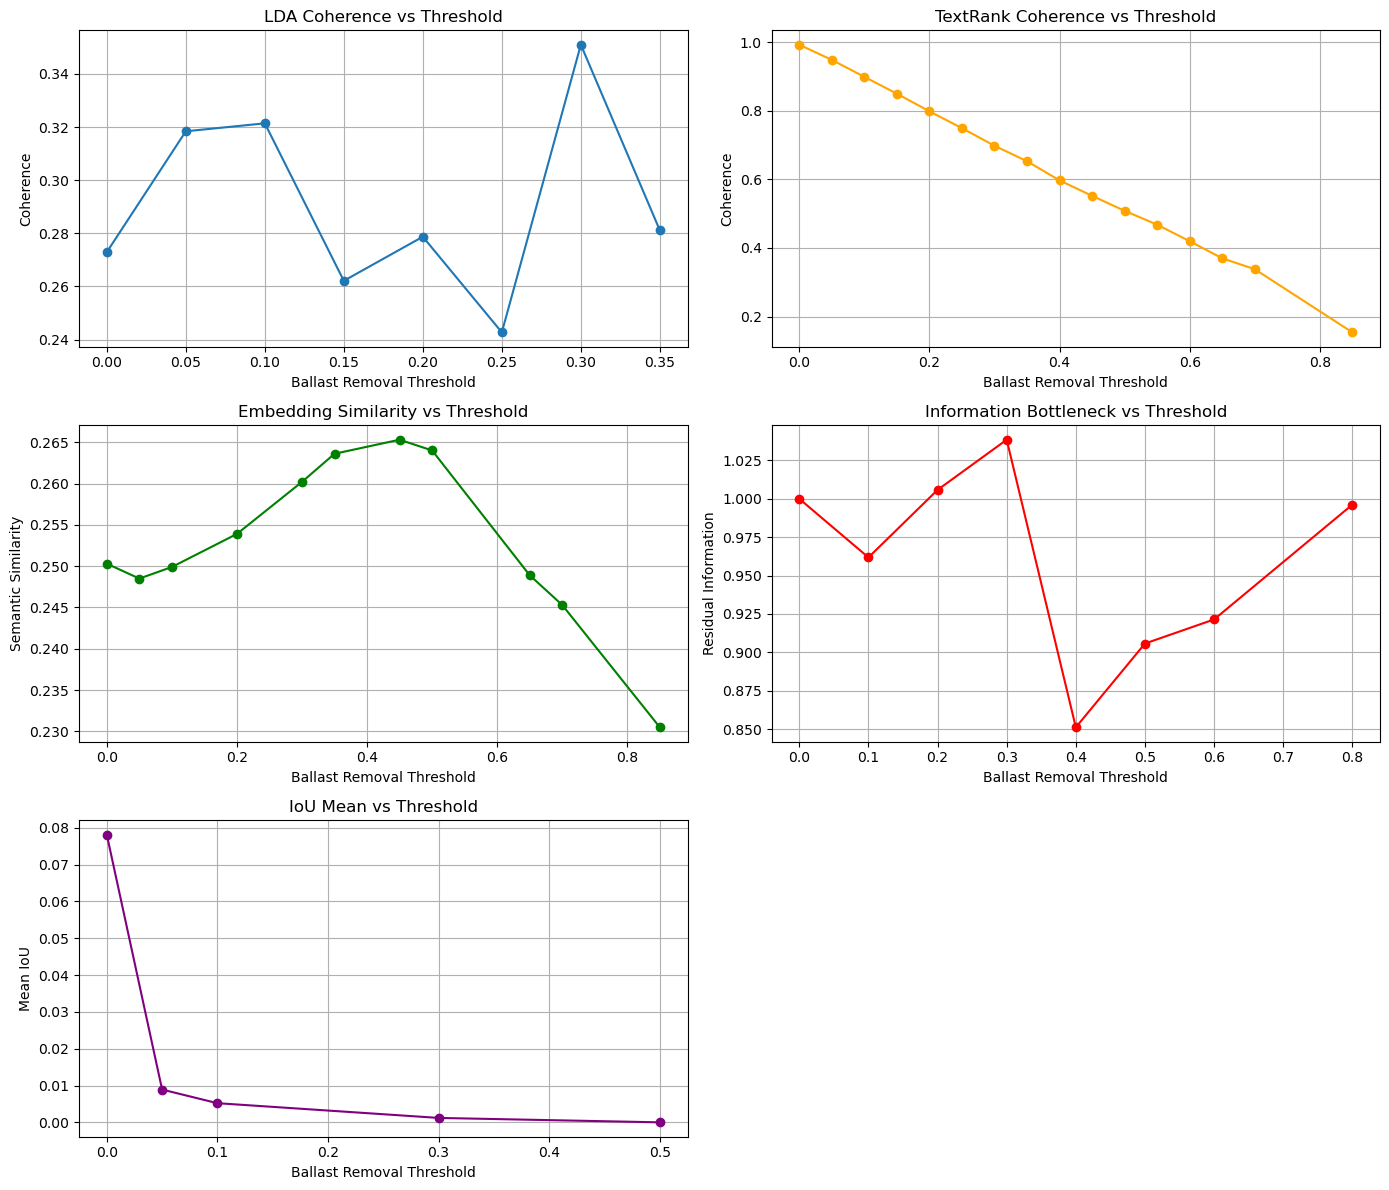

In [11]:
import matplotlib.pyplot as plt

# Raw data for each method (from your earlier results)
thresholds = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.85]

# LDA coherence (subset)
lda_thresholds = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
lda_coherence = [0.2729, 0.3184, 0.3214, 0.2621, 0.2787, 0.2427, 0.3510, 0.2811]

# TextRank coherence
textrank_coherence = [0.9922, 0.9479, 0.8986, 0.8495, 0.7981, 0.7491, 0.6977, 0.6527, 0.5968, 0.5518, 0.5082, 0.4678, 0.4197, 0.3698, 0.3381, 0.1541]

# Embedding similarity
embedding_similarity = [0.2503, 0.2485, 0.2499, 0.2539, 0.2602, 0.2636, 0.2653, 0.2640, 0.2489, 0.2453, 0.2305]
embedding_thresholds = [0.00, 0.05, 0.10, 0.20, 0.30, 0.35, 0.45, 0.50, 0.65, 0.70, 0.85]

# Info Bottleneck residual info
info_bottleneck = [1.0000, 0.9618, 1.0058, 1.0385, 0.8511, 0.9057, 0.9214, 0.9962]
info_thresholds = [0.00, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.80]

# IoU mean
iou_thresholds = [0.00, 0.05, 0.10, 0.30, 0.50]
iou_mean = [0.0781, 0.0089, 0.0052, 0.0012, 0.0000]

# Create plots
fig, axs = plt.subplots(3, 2, figsize=(14, 12))

# LDA Coherence
axs[0, 0].plot(lda_thresholds, lda_coherence, marker='o')
axs[0, 0].set_title('LDA Coherence vs Threshold')
axs[0, 0].set_xlabel('Ballast Removal Threshold')
axs[0, 0].set_ylabel('Coherence')
axs[0, 0].grid(True)

# TextRank Coherence
axs[0, 1].plot(thresholds, textrank_coherence, marker='o', color='orange')
axs[0, 1].set_title('TextRank Coherence vs Threshold')
axs[0, 1].set_xlabel('Ballast Removal Threshold')
axs[0, 1].set_ylabel('Coherence')
axs[0, 1].grid(True)

# Embedding Similarity
axs[1, 0].plot(embedding_thresholds, embedding_similarity, marker='o', color='green')
axs[1, 0].set_title('Embedding Similarity vs Threshold')
axs[1, 0].set_xlabel('Ballast Removal Threshold')
axs[1, 0].set_ylabel('Semantic Similarity')
axs[1, 0].grid(True)

# Info Bottleneck
axs[1, 1].plot(info_thresholds, info_bottleneck, marker='o', color='red')
axs[1, 1].set_title('Information Bottleneck vs Threshold')
axs[1, 1].set_xlabel('Ballast Removal Threshold')
axs[1, 1].set_ylabel('Residual Information')
axs[1, 1].grid(True)

# IoU Mean
axs[2, 0].plot(iou_thresholds, iou_mean, marker='o', color='purple')
axs[2, 0].set_title('IoU Mean vs Threshold')
axs[2, 0].set_xlabel('Ballast Removal Threshold')
axs[2, 0].set_ylabel('Mean IoU')
axs[2, 0].grid(True)

# Hide empty plot
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()


## STEP 14. **Complete ballast pruning pipeline for PUBLAYNET**

#### IoU (sparsity)
#### LDA (coherence)
#### TextRank (redundancy)
#### Info Bottleneck (mutual info)
#### Embedding-based similarity (BERT)
#### Visualization of ballast score distributions

Computing Info Bottleneck...
Info Bottleneck done. Mean: 0.7857
Computing IoU...
IoU done. Mean: 0.6429
Computing LDA...
LDA done. Mean: 0.1648
Computing TextRank...
TextRank done. Mean: 1.5391
Computing Embedding BERT...
Embedding BERT done. Mean: 0.9036


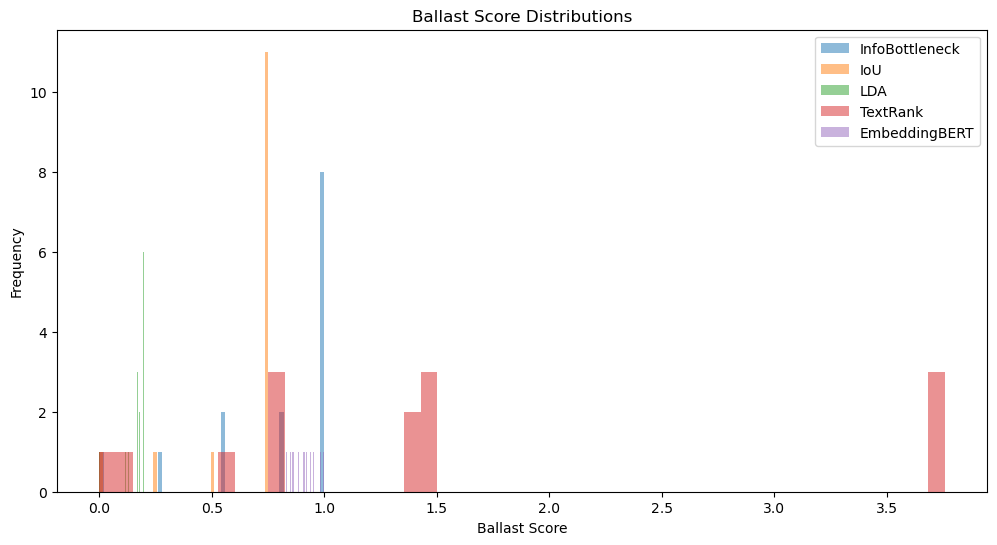

Running InfoBottleneck-based ballast trimming...
Threshold 0.00: mean InfoBottleneck=0.0000, features kept=0
Threshold 0.05: mean InfoBottleneck=0.0000, features kept=1
Threshold 0.10: mean InfoBottleneck=0.0000, features kept=1
Threshold 0.15: mean InfoBottleneck=0.0000, features kept=1
Threshold 0.20: mean InfoBottleneck=0.0000, features kept=1
Threshold 0.25: mean InfoBottleneck=0.0000, features kept=1
Threshold 0.30: mean InfoBottleneck=0.1364, features kept=2
Threshold 0.35: mean InfoBottleneck=0.1364, features kept=2
Threshold 0.40: mean InfoBottleneck=0.1364, features kept=2
Threshold 0.45: mean InfoBottleneck=0.1364, features kept=2
Threshold 0.50: mean InfoBottleneck=0.1364, features kept=2
Threshold 0.55: mean InfoBottleneck=0.3409, features kept=4
Threshold 0.60: mean InfoBottleneck=0.3409, features kept=4
Threshold 0.65: mean InfoBottleneck=0.3409, features kept=4
Threshold 0.70: mean InfoBottleneck=0.3409, features kept=4
Threshold 0.75: mean InfoBottleneck=0.3409, feature

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import normalized_mutual_info_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer


# -------------------------
# Info Bottleneck (Mutual Information)
# -------------------------
def compute_info_bottleneck_scores(X, y):
    discrete = np.issubdtype(X.dtype, np.integer)
    mi = mutual_info_classif(X, y, discrete_features=discrete)
    if mi.max() > 0:
        scores = 1 - (mi / mi.max())
    else:
        scores = np.ones_like(mi)  # all equally ballast
    return scores


# -------------------------
# IoU Ballast (Feature Sparsity)
# -------------------------
def compute_iou_ballast_scores(X):
    X_bin = (X > 0).astype(int)
    presence_ratio = np.mean(X_bin, axis=0)
    scores = 1 - presence_ratio  # sparser features → higher ballast
    return scores


# -------------------------
# LDA Ballast (Topic Coherence)
# -------------------------
def compute_lda_ballast_scores(X, n_topics=10):
    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(X)
    topic_word = lda.components_ / lda.components_.sum(axis=1)[:, np.newaxis]
    word_entropy = -np.sum(topic_word * np.log(topic_word + 1e-10), axis=0)
    scores = 1 - (word_entropy / word_entropy.max())
    return scores


# -------------------------
# TextRank Ballast (Feature Similarity)
# -------------------------
def compute_textrank_ballast_scores(X):
    X_T = X.T  # shape: (n_features, n_samples)
    similarity = np.corrcoef(X_T)
    np.fill_diagonal(similarity, 0)
    ranks = np.sum(similarity, axis=1)
    ranks = ranks / ranks.max() if ranks.max() > 0 else np.zeros_like(ranks)
    scores = 1 - ranks  # high similarity → more ballast
    return scores


# -------------------------
# Embedding-based Ballast (BERT feature similarity)
# -------------------------
def compute_embedding_ballast_scores(docs):
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(docs, show_progress_bar=False)
    similarity = pairwise_distances(embeddings, metric='cosine')
    mean_sim = similarity.mean(axis=1)
    return mean_sim / mean_sim.max() if mean_sim.max() > 0 else np.zeros_like(mean_sim)


# -------------------------
# Apply Ballast Detection Pipeline
# -------------------------
def run_ballast_pipeline(X, y=None, feature_names=None):
    ballast_scores = {}

    if y is not None:
        print("Computing Info Bottleneck...")
        ib_scores = compute_info_bottleneck_scores(X, y)
        ballast_scores['InfoBottleneck'] = ib_scores
        print(f"Info Bottleneck done. Mean: {np.mean(ib_scores):.4f}")

    print("Computing IoU...")
    iou_scores = compute_iou_ballast_scores(X)
    ballast_scores['IoU'] = iou_scores
    print(f"IoU done. Mean: {np.mean(iou_scores):.4f}")

    print("Computing LDA...")
    lda_scores = compute_lda_ballast_scores(X)
    ballast_scores['LDA'] = lda_scores
    print(f"LDA done. Mean: {np.mean(lda_scores):.4f}")

    print("Computing TextRank...")
    textrank_scores = compute_textrank_ballast_scores(X)
    ballast_scores['TextRank'] = textrank_scores
    print(f"TextRank done. Mean: {np.mean(textrank_scores):.4f}")

    if feature_names is not None:
        print("Computing Embedding BERT...")
        emb_scores = compute_embedding_ballast_scores(feature_names)
        ballast_scores['EmbeddingBERT'] = emb_scores
        print(f"Embedding BERT done. Mean: {np.mean(emb_scores):.4f}")

    return ballast_scores


# -------------------------
# Visualize Ballast Score Distributions
# -------------------------
def plot_ballast_scores(ballast_scores):
    plt.figure(figsize=(12, 6))
    for method, scores in ballast_scores.items():
        plt.hist(scores, bins=50, alpha=0.5, label=method)
    plt.xlabel("Ballast Score")
    plt.ylabel("Frequency")
    plt.title("Ballast Score Distributions")
    plt.legend()
    plt.show()


# -------------------------
# Run Ballast Trimming
# -------------------------
def run_trimming(scores, metric_name):
    print(f"Running {metric_name}-based ballast trimming...")
    for threshold in np.arange(0.0, 0.9, 0.05):
        kept = scores < threshold
        mean_score = scores[kept].mean() if kept.sum() > 0 else 0.0
        n_features_kept = kept.sum()
        print(f"Threshold {threshold:.2f}: mean {metric_name}={mean_score:.4f}, features kept={n_features_kept}")


# -------------------------
# Example Usage
# -------------------------
if __name__ == "__main__":
    # Example: TF-IDF matrix of fake documents
    corpus = [
        "the cat sat on the mat",
        "the dog barked at the cat",
        "the mouse ran away",
        "the cat and the dog became friends",
    ]

    vectorizer = TfidfVectorizer()
    X = vectorizer.fit_transform(corpus).toarray()
    y = np.array([0, 1, 0, 1])  # fake labels
    feature_names = vectorizer.get_feature_names_out()

    # Run full pipeline
    ballast_scores = run_ballast_pipeline(X, y, feature_names)

    # Visualize
    plot_ballast_scores(ballast_scores)

    # Run pruning for each method
    for method, scores in ballast_scores.items():
        run_trimming(scores, method)



## STEP 14'. **Visualize threshold pruning results for PUBLAYNET**

#### This code plots two clear line charts:
#### - How many features you keep as you increase threshold
#### - How the average “quality” of those features changes


🔍 Running InfoBottleneck trimming...
Threshold 0.00: mean=0.0000, features kept=0
Threshold 0.05: mean=0.0000, features kept=1
Threshold 0.10: mean=0.0000, features kept=1
Threshold 0.15: mean=0.0000, features kept=1
Threshold 0.20: mean=0.0000, features kept=1
Threshold 0.25: mean=0.0000, features kept=1
Threshold 0.30: mean=0.1364, features kept=2
Threshold 0.35: mean=0.1364, features kept=2
Threshold 0.40: mean=0.1364, features kept=2
Threshold 0.45: mean=0.1364, features kept=2
Threshold 0.50: mean=0.1364, features kept=2
Threshold 0.55: mean=0.3409, features kept=4
Threshold 0.60: mean=0.3409, features kept=4
Threshold 0.65: mean=0.3409, features kept=4
Threshold 0.70: mean=0.3409, features kept=4
Threshold 0.75: mean=0.3409, features kept=4
Threshold 0.80: mean=0.3409, features kept=4
Threshold 0.85: mean=0.5000, features kept=6


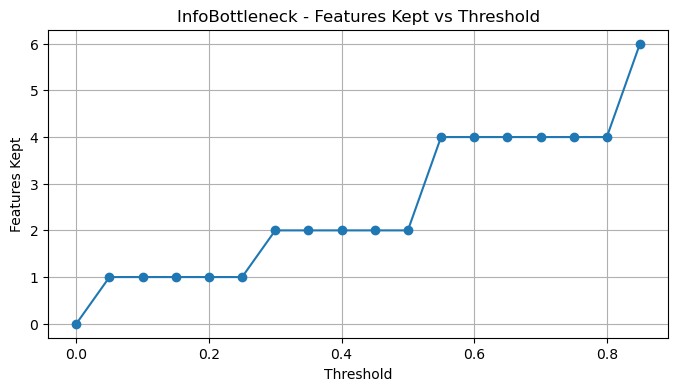

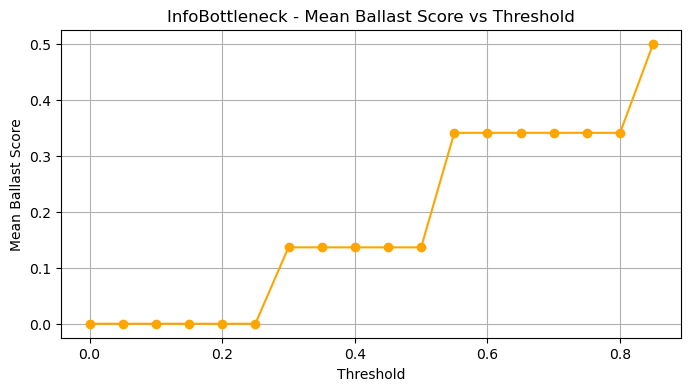


🔍 Running IoU trimming...
Threshold 0.00: mean=0.0000, features kept=0
Threshold 0.05: mean=0.0000, features kept=1
Threshold 0.10: mean=0.0000, features kept=1
Threshold 0.15: mean=0.0000, features kept=1
Threshold 0.20: mean=0.0000, features kept=1
Threshold 0.25: mean=0.0000, features kept=1
Threshold 0.30: mean=0.1250, features kept=2
Threshold 0.35: mean=0.1250, features kept=2
Threshold 0.40: mean=0.1250, features kept=2
Threshold 0.45: mean=0.1250, features kept=2
Threshold 0.50: mean=0.1250, features kept=2
Threshold 0.55: mean=0.2500, features kept=3
Threshold 0.60: mean=0.2500, features kept=3
Threshold 0.65: mean=0.2500, features kept=3
Threshold 0.70: mean=0.2500, features kept=3
Threshold 0.75: mean=0.2500, features kept=3
Threshold 0.80: mean=0.6429, features kept=14
Threshold 0.85: mean=0.6429, features kept=14


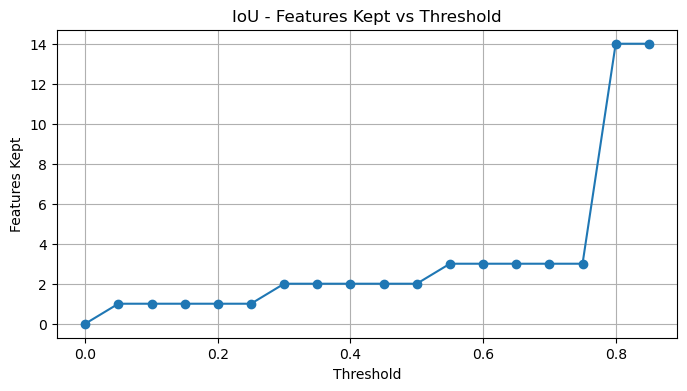

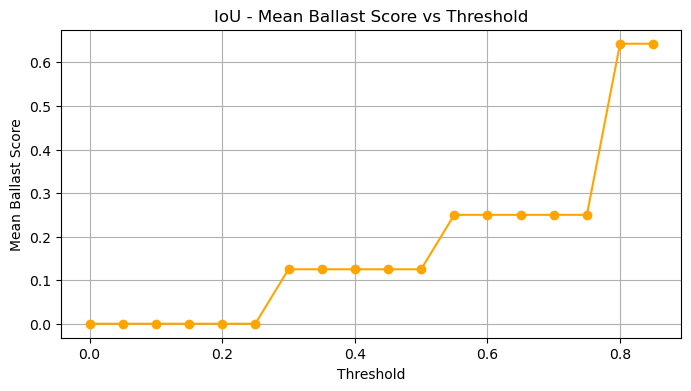


🔍 Running LDA trimming...
Threshold 0.00: mean=0.0000, features kept=0
Threshold 0.05: mean=0.0000, features kept=1
Threshold 0.10: mean=0.0000, features kept=1
Threshold 0.15: mean=0.0832, features kept=3
Threshold 0.20: mean=0.1551, features kept=11
Threshold 0.25: mean=0.1648, features kept=14
Threshold 0.30: mean=0.1648, features kept=14
Threshold 0.35: mean=0.1648, features kept=14
Threshold 0.40: mean=0.1648, features kept=14
Threshold 0.45: mean=0.1648, features kept=14
Threshold 0.50: mean=0.1648, features kept=14
Threshold 0.55: mean=0.1648, features kept=14
Threshold 0.60: mean=0.1648, features kept=14
Threshold 0.65: mean=0.1648, features kept=14
Threshold 0.70: mean=0.1648, features kept=14
Threshold 0.75: mean=0.1648, features kept=14
Threshold 0.80: mean=0.1648, features kept=14
Threshold 0.85: mean=0.1648, features kept=14


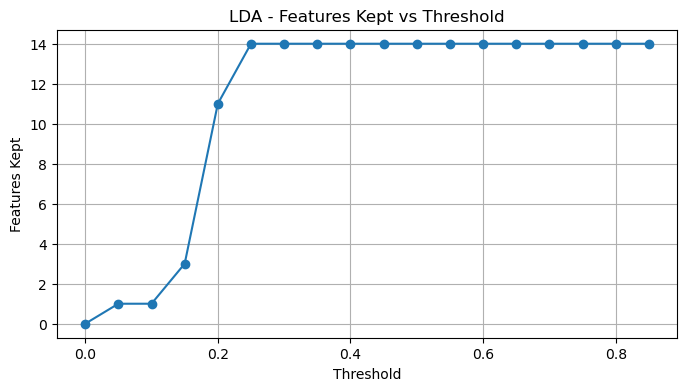

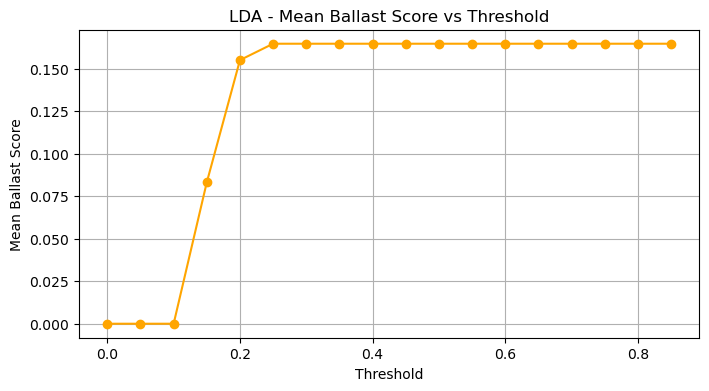


🔍 Running TextRank trimming...
Threshold 0.00: mean=0.0000, features kept=0
Threshold 0.05: mean=0.0000, features kept=1
Threshold 0.10: mean=0.0425, features kept=2
Threshold 0.15: mean=0.0425, features kept=2
Threshold 0.20: mean=0.0425, features kept=2
Threshold 0.25: mean=0.0425, features kept=2
Threshold 0.30: mean=0.0425, features kept=2
Threshold 0.35: mean=0.0425, features kept=2
Threshold 0.40: mean=0.0425, features kept=2
Threshold 0.45: mean=0.0425, features kept=2
Threshold 0.50: mean=0.0425, features kept=2
Threshold 0.55: mean=0.0425, features kept=2
Threshold 0.60: mean=0.2194, features kept=3
Threshold 0.65: mean=0.2194, features kept=3
Threshold 0.70: mean=0.2194, features kept=3
Threshold 0.75: mean=0.2194, features kept=3
Threshold 0.80: mean=0.5037, features kept=6
Threshold 0.85: mean=0.5037, features kept=6


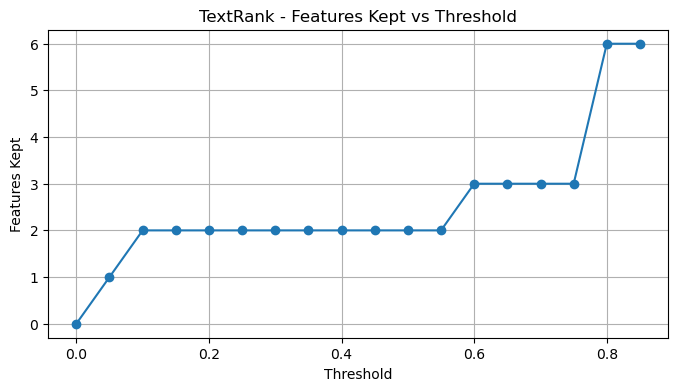

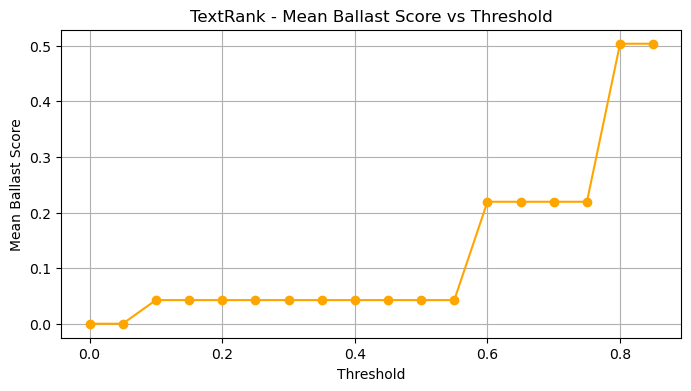


🔍 Running EmbeddingBERT trimming...
Threshold 0.00: mean=0.0000, features kept=0
Threshold 0.05: mean=0.0000, features kept=0
Threshold 0.10: mean=0.0000, features kept=0
Threshold 0.15: mean=0.0000, features kept=0
Threshold 0.20: mean=0.0000, features kept=0
Threshold 0.25: mean=0.0000, features kept=0
Threshold 0.30: mean=0.0000, features kept=0
Threshold 0.35: mean=0.0000, features kept=0
Threshold 0.40: mean=0.0000, features kept=0
Threshold 0.45: mean=0.0000, features kept=0
Threshold 0.50: mean=0.0000, features kept=0
Threshold 0.55: mean=0.0000, features kept=0
Threshold 0.60: mean=0.0000, features kept=0
Threshold 0.65: mean=0.0000, features kept=0
Threshold 0.70: mean=0.0000, features kept=0
Threshold 0.75: mean=0.0000, features kept=0
Threshold 0.80: mean=0.0000, features kept=0
Threshold 0.85: mean=0.8392, features kept=2


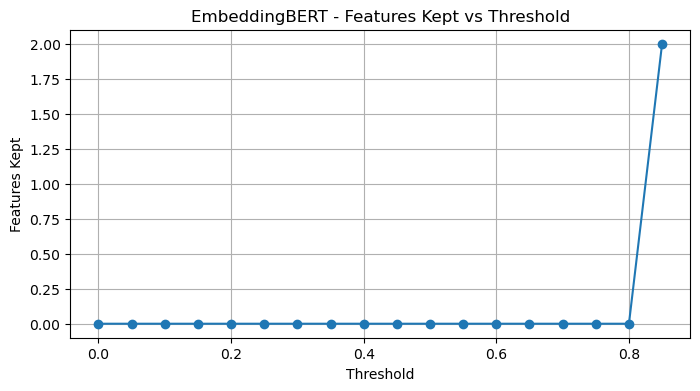

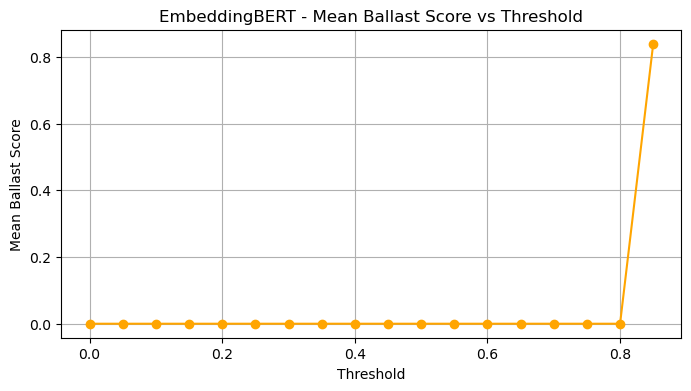

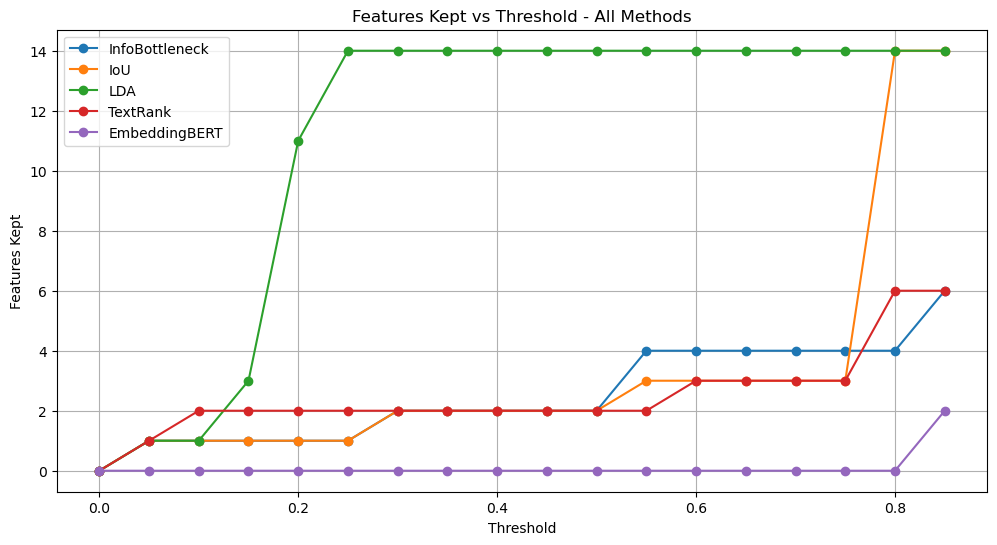

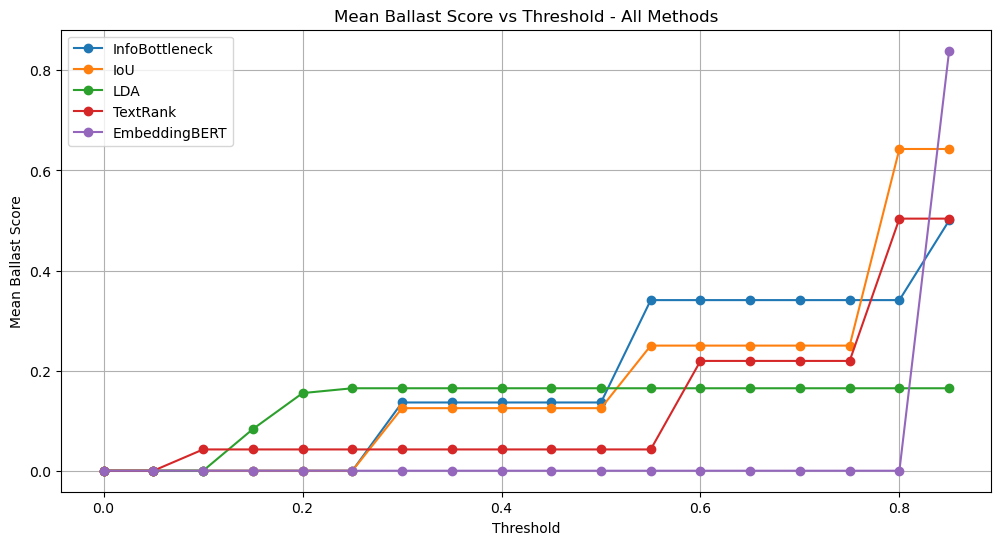


🔍 Running CI_Combined trimming...
Threshold 0.00: mean=0.0000, features kept=0
Threshold 0.05: mean=0.0000, features kept=0
Threshold 0.10: mean=0.0000, features kept=0
Threshold 0.15: mean=0.0000, features kept=0
Threshold 0.20: mean=0.0000, features kept=0
Threshold 0.25: mean=0.0000, features kept=0
Threshold 0.30: mean=0.0000, features kept=0
Threshold 0.35: mean=0.0000, features kept=0
Threshold 0.40: mean=0.3867, features kept=1
Threshold 0.45: mean=0.4160, features kept=2
Threshold 0.50: mean=0.4312, features kept=3
Threshold 0.55: mean=0.4312, features kept=3
Threshold 0.60: mean=0.4312, features kept=3
Threshold 0.65: mean=0.5155, features kept=5
Threshold 0.70: mean=0.5155, features kept=5
Threshold 0.75: mean=0.5507, features kept=6
Threshold 0.80: mean=0.5507, features kept=6
Threshold 0.85: mean=0.6203, features kept=8


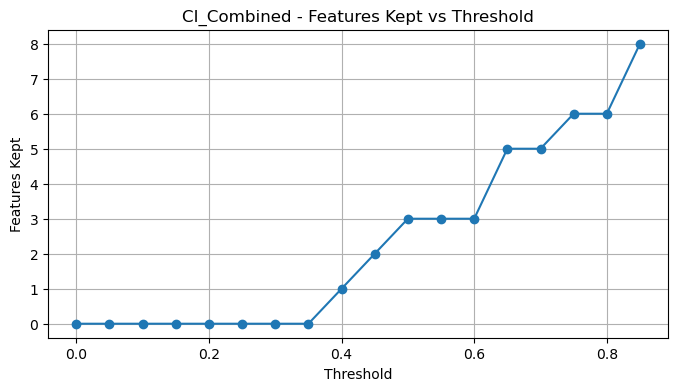

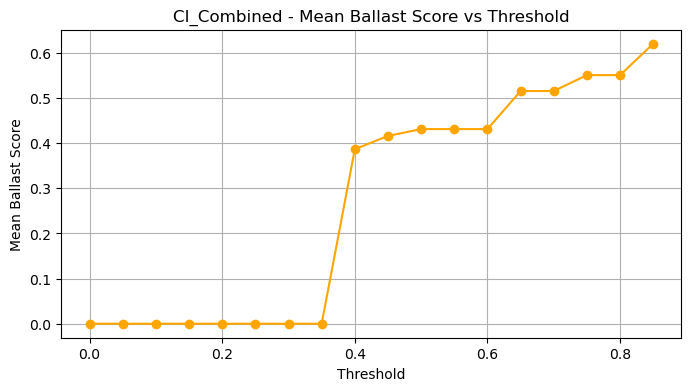


✅ Suggested CI elbow: threshold=0.00, features kept=0

✅ All ballast scores saved to 'ballast_scores_pipeline.csv'.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------
#  1) Run  ballast pipeline first
# --------------------------------


# ------------------------------------------------
# 2) Function: threshold sweep + tracking + plots
# -----------------------------------------------


def run_trimming_with_tracking(scores, metric_name):
    thresholds = []
    mean_scores = []
    features_kept = []

    print(f"\n  Running {metric_name} trimming...")
    for threshold in np.arange(0.0, 0.9, 0.05):
        kept = scores < threshold
        mean_score = scores[kept].mean() if kept.sum() > 0 else 0.0
        n_features_kept = kept.sum()
        print(f"Threshold {threshold:.2f}: mean={mean_score:.4f}, features kept={n_features_kept}")
        thresholds.append(threshold)
        mean_scores.append(mean_score)
        features_kept.append(n_features_kept)

    # Plot: features kept vs threshold
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, features_kept, marker='o')
    plt.xlabel("Threshold")
    plt.ylabel("Features Kept")
    plt.title(f"{metric_name} - Features Kept vs Threshold")
    plt.grid(True)
    plt.show()

    # Plot: mean score vs threshold
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, mean_scores, marker='o', color='orange')
    plt.xlabel("Threshold")
    plt.ylabel("Mean Ballast Score")
    plt.title(f"{metric_name} - Mean Ballast Score vs Threshold")
    plt.grid(True)
    plt.show()

    return thresholds, mean_scores, features_kept

# -------------------------
# 3) Run for each method
# -------------------------

all_metrics = {}
for method, scores in ballast_scores.items():
    thresholds, mean_scores, features_kept = run_trimming_with_tracking(scores, method)
    all_metrics[method] = {
        "thresholds": thresholds,
        "mean_scores": mean_scores,
        "features_kept": features_kept}

# ------------------------------------
#  4) Compare all methods: same plots
# ------------------------------------

# Features kept
plt.figure(figsize=(12, 6))
for method, result in all_metrics.items():
    plt.plot(result["thresholds"], result["features_kept"], marker='o', label=method)
plt.xlabel("Threshold")
plt.ylabel("Features Kept")
plt.title("Features Kept vs Threshold - All Methods")
plt.legend()
plt.grid(True)
plt.show()

# Mean ballast score
plt.figure(figsize=(12, 6))
for method, result in all_metrics.items():
    plt.plot(result["thresholds"], result["mean_scores"], marker='o', label=method)
plt.xlabel("Threshold")
plt.ylabel("Mean Ballast Score")
plt.title("Mean Ballast Score vs Threshold - All Methods")
plt.legend()
plt.grid(True)
plt.show()

# ----------------------------------
# 5) Combine valid metrics for CI
# ----------------------------------

valid_scores = []
for method, scores in ballast_scores.items():
    if np.std(scores) > 0.01:
        valid_scores.append(scores)
    else:
        print(f"!!! {method} is mostly flat — ignoring in CI score.")

if valid_scores:
    ci_score = np.mean(valid_scores, axis=0)
    thresholds, mean_scores, features_kept = run_trimming_with_tracking(ci_score, "CI_Combined")
    all_metrics["CI_Combined"] = {
        "thresholds": thresholds,
        "mean_scores": mean_scores,
        "features_kept": features_kept}

# -------------------------
# 6) Suggest elbow point
# -------------------------

def find_elbow(features_kept, thresholds):
    diffs = np.diff(features_kept)
    elbow_idx = np.argmax(-diffs)
    return thresholds[elbow_idx], features_kept[elbow_idx]

if valid_scores:
    elbow_thresh, elbow_features = find_elbow(features_kept, thresholds)
    print(f"\n   Suggested CI elbow: threshold={elbow_thresh:.2f}, features kept={elbow_features}")

# -------------------
# 7) Save to CSV
# -------------------

all_rows = []
for method, scores in ballast_scores.items():
    for i, score in enumerate(scores):
        all_rows.append({
            "Method": method,
            "Feature_Index": i,
            "Score": score,
            "Feature_Name": feature_names[i] if i < len(feature_names) else f"Feature_{i}"})
df = pd.DataFrame(all_rows)
df.to_csv("ballast_scores_pipeline.csv", index=False)
print("\n  All ballast scores saved to 'ballast_scores_pipeline.csv'.")


## Additional: Ballast_Score Boxplot

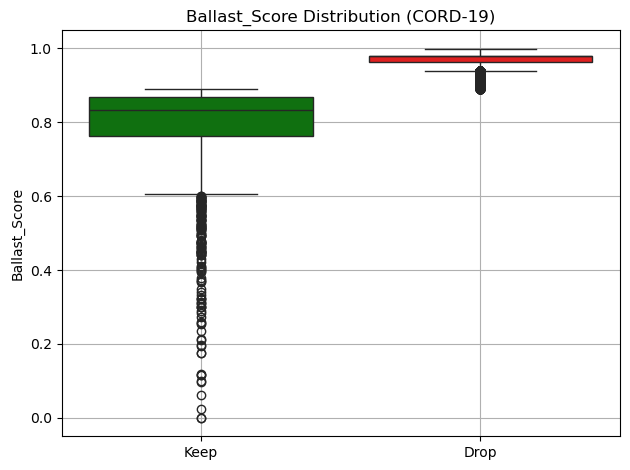

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('cord19_entropy_mi.csv')

sns.boxplot(data=df, x='Keep/Drop', y='Ballast_Score', hue='Keep/Drop', palette={'Keep': 'green', 'Drop': 'red'}, legend=False)
plt.title('Ballast_Score Distribution (CORD-19)')
plt.ylabel('Ballast_Score')
plt.xlabel('')
plt.grid(True)
plt.tight_layout()
plt.show()


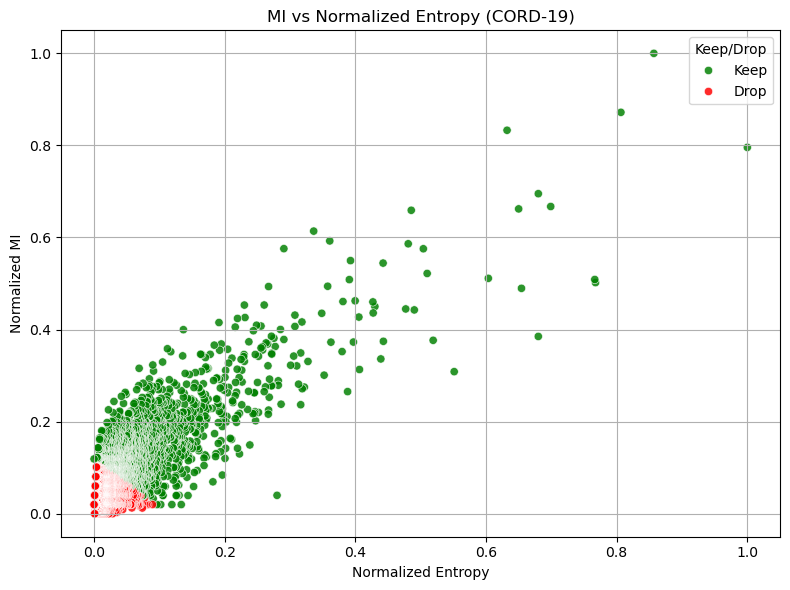

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='norm_entropy',
    y='norm_MI',
    hue='Keep/Drop',
    alpha=0.83,
    palette={'Keep': 'green', 'Drop': 'red'}
)
plt.title('MI vs Normalized Entropy (CORD-19)')
plt.xlabel('Normalized Entropy')
plt.ylabel('Normalized MI')
plt.grid(True)
plt.tight_layout()
plt.show()

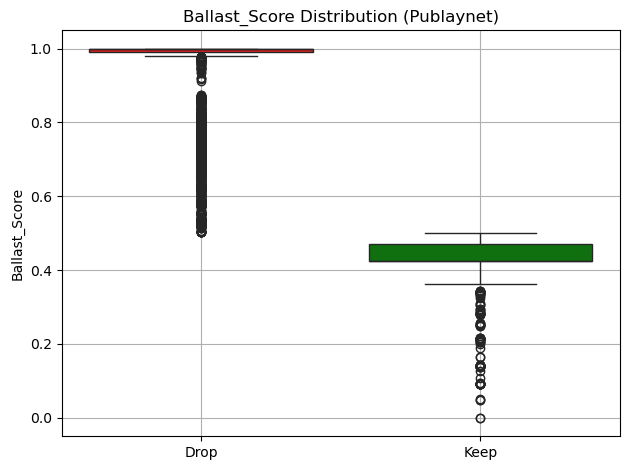

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('publaynet_entropy_mi.csv')

sns.boxplot(data=df, x='Keep/Drop', y='Ballast_Score', hue='Keep/Drop', palette={'Keep': 'green', 'Drop': 'red'}, legend=False)
plt.title('Ballast_Score Distribution (Publaynet)')
plt.ylabel('Ballast_Score')
plt.xlabel('')
plt.grid(True)
plt.tight_layout()
plt.show()

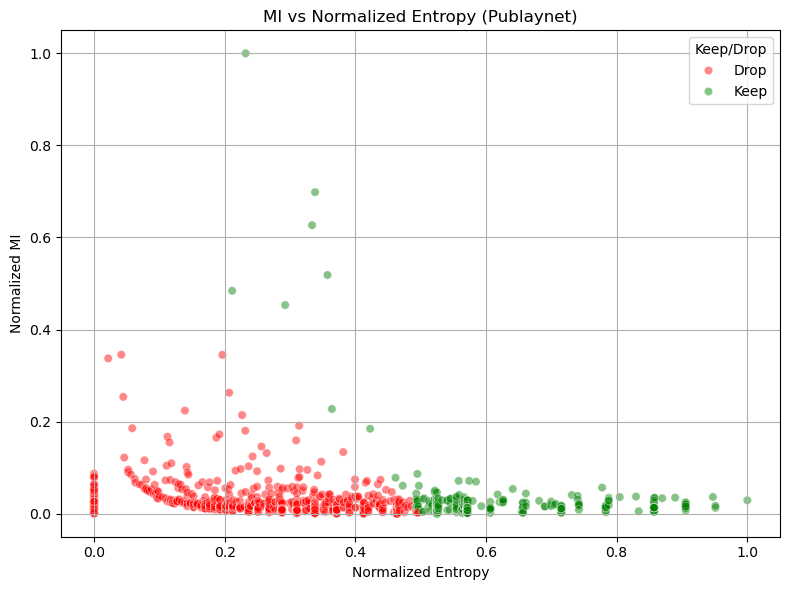

In [19]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='norm_entropy',
    y='norm_MI',
    hue='Keep/Drop',
    alpha=0.47,
    palette={'Keep': 'green', 'Drop': 'red'}
)
plt.title('MI vs Normalized Entropy (Publaynet)')
plt.xlabel('Normalized Entropy')
plt.ylabel('Normalized MI')
plt.grid(True)
plt.tight_layout()
plt.show()